<a href="https://www.kaggle.com/code/lalit7881/robusta-mulch-seedling-dataset-eda-100?scriptVersionId=318426576" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sandhyapalaniappan/robusta-coffee-waste-mulch-seedling-data-atlas/robusta_coffee_waste_mulch_seedling_physiology_dataset.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/sandhyapalaniappan/robusta-coffee-waste-mulch-seedling-data-atlas/robusta_coffee_waste_mulch_seedling_physiology_dataset.csv")

In [3]:
df.head()

,experimental_observation_id,mulching_treatment_code,mulching_treatment_description,soil_moisture_percent,soil_temperature_celsius,ambient_air_temperature_celsius,soil_ph_value,soil_bulk_density_g_cm3,soil_organic_matter_content,soil_available_potassium_content,...,spad_chlorophyll_index,stomatal_conductance_index,intercellular_carbon_dioxide_concentration_ci,net_photosynthetic_rate_pn,leaf_respiration_rate_r,gross_photosynthetic_rate_pg,transpiration_rate_mmol,carbon_use_efficiency_cue,net_water_use_efficiency_wuen,gross_water_use_efficiency_wueg
0,1,C,Control treatment,5.65,27.45,24.924777,6.153333,1.253784,22.055707,16.344375,...,52.6,0.041625,227.530256,0.530015,1.618717,2.148731,0.533953,0.246664,0.992623,4.024194
1,2,C,Control treatment,8.70,27.55,25.068246,6.186667,1.609579,27.629973,41.311681,...,74.6,0.024155,160.052644,1.419099,0.736510,2.155609,0.271670,0.658329,5.223620,7.934670
2,3,C,Control treatment,10.90,27.80,25.125644,5.103333,1.503000,18.693907,51.465462,...,87.7,0.025958,246.200508,0.244299,0.411629,0.655928,0.297812,0.372448,0.820315,2.202493
3,4,C,Control treatment,10.30,27.45,25.212975,5.230000,1.776526,18.992733,22.198172,...,53.8,0.037692,240.578107,0.176486,0.677203,0.853690,0.466010,0.206734,0.378718,1.831914
4,5,C,Control treatment,6.95,27.65,25.243258,4.630000,1.632123,25.509453,40.501189,...,45.2,0.049975,214.525482,1.069365,1.423340,2.492705,0.629531,0.428998,1.698670,3.959624


In [4]:
df.tail()

,experimental_observation_id,mulching_treatment_code,mulching_treatment_description,soil_moisture_percent,soil_temperature_celsius,ambient_air_temperature_celsius,soil_ph_value,soil_bulk_density_g_cm3,soil_organic_matter_content,soil_available_potassium_content,...,spad_chlorophyll_index,stomatal_conductance_index,intercellular_carbon_dioxide_concentration_ci,net_photosynthetic_rate_pn,leaf_respiration_rate_r,gross_photosynthetic_rate_pg,transpiration_rate_mmol,carbon_use_efficiency_cue,net_water_use_efficiency_wuen,gross_water_use_efficiency_wueg
19,26,LP,Combined coffee litter and cascara mulching tr...,9.50,26.85,26.088709,6.583333,1.653616,21.239680,35.618242,...,61.4,0.033203,188.500754,1.345013,3.647141,4.992154,0.358112,0.269425,3.755848,13.940217
20,27,LP,Combined coffee litter and cascara mulching tr...,4.95,27.20,26.110172,5.970000,1.409493,30.014840,37.716048,...,50.1,0.025805,200.865081,5.082870,2.449700,7.532570,0.276044,0.674786,8.413237,17.287537
21,28,LP,Combined coffee litter and cascara mulching tr...,8.25,27.30,26.236775,5.633333,1.503645,11.426667,82.792667,...,53.7,0.058949,231.731093,0.732741,0.524173,1.256915,0.757187,0.582968,0.967715,1.659979
22,29,LP,Combined coffee litter and cascara mulching tr...,5.95,27.15,26.245886,5.870000,1.962215,28.093333,43.716000,...,55.6,0.042335,143.545297,3.054894,0.443746,3.498639,0.492118,0.873166,6.207648,7.109355
23,30,LP,Combined coffee litter and cascara mulching tr...,13.50,27.30,26.231153,5.605000,1.362112,16.590000,90.253500,...,67.9,0.039724,244.722570,2.674087,2.121727,4.795814,0.461131,0.557588,5.798975,10.400114


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 27 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   experimental_observation_id                    24 non-null     int64  
 1   mulching_treatment_code                        24 non-null     object 
 2   mulching_treatment_description                 24 non-null     object 
 3   soil_moisture_percent                          24 non-null     float64
 4   soil_temperature_celsius                       24 non-null     float64
 5   ambient_air_temperature_celsius                24 non-null     float64
 6   soil_ph_value                                  24 non-null     float64
 7   soil_bulk_density_g_cm3                        24 non-null     float64
 8   soil_organic_matter_content                    24 non-null     float64
 9   soil_available_potassium_content               24 non-nu

In [6]:
df.describe()

,experimental_observation_id,soil_moisture_percent,soil_temperature_celsius,ambient_air_temperature_celsius,soil_ph_value,soil_bulk_density_g_cm3,soil_organic_matter_content,soil_available_potassium_content,soil_available_phosphorus_content,soil_alkali_hydrolysable_nitrogen_content,...,spad_chlorophyll_index,stomatal_conductance_index,intercellular_carbon_dioxide_concentration_ci,net_photosynthetic_rate_pn,leaf_respiration_rate_r,gross_photosynthetic_rate_pg,transpiration_rate_mmol,carbon_use_efficiency_cue,net_water_use_efficiency_wuen,gross_water_use_efficiency_wueg
count,24.00000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,...,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000
mean,15.50000,8.081667,27.333333,25.742407,5.632431,1.591760,21.674660,42.657756,29.738651,89.853876,...,60.708333,0.045367,193.346856,1.935550,1.633671,3.569221,0.525678,0.525232,3.743802,7.149771
std,9.84665,2.172682,0.203056,0.412957,0.601360,0.211407,6.216381,19.054798,17.779924,32.067442,...,13.961871,0.014347,43.868338,1.414165,1.162711,2.082953,0.161764,0.213363,2.704781,4.424407
min,1.00000,4.950000,26.850000,24.924777,4.526667,1.201667,10.993373,13.051057,9.730831,23.333333,...,45.200000,0.024155,77.358450,0.176486,0.265297,0.655928,0.271670,0.188559,0.378718,1.659979
25%,6.75000,6.337500,27.237500,25.374068,5.292500,1.497398,17.728310,32.851403,15.364892,75.250000,...,52.100000,0.034616,170.123943,1.010939,0.712390,2.085979,0.396247,0.338136,1.412347,3.495355
50%,15.50000,7.675000,27.300000,25.885771,5.569167,1.587322,21.090267,40.906435,24.581781,87.500000,...,55.400000,0.041980,200.731824,1.465187,1.368587,3.299774,0.500309,0.575803,2.808978,7.142099
75%,24.25000,9.550000,27.450000,26.046866,6.012500,1.710911,27.367063,46.929393,37.481086,116.316667,...,63.850000,0.059240,228.341928,2.833747,2.203721,4.778557,0.643738,0.683364,5.901143,10.353681
max,30.00000,13.500000,27.800000,26.245886,6.740000,1.962215,32.727267,90.253500,70.501722,142.333333,...,89.800000,0.071596,246.200508,5.082870,4.270848,8.005150,0.773446,0.873166,8.988644,17.287537


In [7]:
df.isnull().sum()

experimental_observation_id                      0
mulching_treatment_code                          0
mulching_treatment_description                   0
soil_moisture_percent                            0
soil_temperature_celsius                         0
ambient_air_temperature_celsius                  0
soil_ph_value                                    0
soil_bulk_density_g_cm3                          0
soil_organic_matter_content                      0
soil_available_potassium_content                 0
soil_available_phosphorus_content                0
soil_alkali_hydrolysable_nitrogen_content        0
seedling_height_increment                        0
leaf_biomass_weight_g                            0
total_leaf_area_cm2                              0
specific_leaf_area_g_per_cm2                     0
leaf_count                                       0
spad_chlorophyll_index                           0
stomatal_conductance_index                       0
intercellular_carbon_dioxide_co

In [8]:
df.dtypes

experimental_observation_id                        int64
mulching_treatment_code                           object
mulching_treatment_description                    object
soil_moisture_percent                            float64
soil_temperature_celsius                         float64
ambient_air_temperature_celsius                  float64
soil_ph_value                                    float64
soil_bulk_density_g_cm3                          float64
soil_organic_matter_content                      float64
soil_available_potassium_content                 float64
soil_available_phosphorus_content                float64
soil_alkali_hydrolysable_nitrogen_content        float64
seedling_height_increment                        float64
leaf_biomass_weight_g                            float64
total_leaf_area_cm2                              float64
specific_leaf_area_g_per_cm2                     float64
leaf_count                                         int64
spad_chlorophyll_index         

In [9]:
df.shape

(24, 27)

In [10]:
df.columns

Index(['experimental_observation_id', 'mulching_treatment_code',
       'mulching_treatment_description', 'soil_moisture_percent',
       'soil_temperature_celsius', 'ambient_air_temperature_celsius',
       'soil_ph_value', 'soil_bulk_density_g_cm3',
       'soil_organic_matter_content', 'soil_available_potassium_content',
       'soil_available_phosphorus_content',
       'soil_alkali_hydrolysable_nitrogen_content',
       'seedling_height_increment', 'leaf_biomass_weight_g',
       'total_leaf_area_cm2', 'specific_leaf_area_g_per_cm2', 'leaf_count',
       'spad_chlorophyll_index', 'stomatal_conductance_index',
       'intercellular_carbon_dioxide_concentration_ci',
       'net_photosynthetic_rate_pn', 'leaf_respiration_rate_r',
       'gross_photosynthetic_rate_pg', 'transpiration_rate_mmol',
       'carbon_use_efficiency_cue', 'net_water_use_efficiency_wuen',
       'gross_water_use_efficiency_wueg'],
      dtype='object')

In [11]:
df.nunique()

experimental_observation_id                      24
mulching_treatment_code                           4
mulching_treatment_description                    4
soil_moisture_percent                            23
soil_temperature_celsius                         12
ambient_air_temperature_celsius                  24
soil_ph_value                                    24
soil_bulk_density_g_cm3                          24
soil_organic_matter_content                      24
soil_available_potassium_content                 24
soil_available_phosphorus_content                24
soil_alkali_hydrolysable_nitrogen_content        23
seedling_height_increment                        20
leaf_biomass_weight_g                            23
total_leaf_area_cm2                              24
specific_leaf_area_g_per_cm2                     24
leaf_count                                        4
spad_chlorophyll_index                           24
stomatal_conductance_index                       24
intercellula

In [12]:
df.isnull()

,experimental_observation_id,mulching_treatment_code,mulching_treatment_description,soil_moisture_percent,soil_temperature_celsius,ambient_air_temperature_celsius,soil_ph_value,soil_bulk_density_g_cm3,soil_organic_matter_content,soil_available_potassium_content,...,spad_chlorophyll_index,stomatal_conductance_index,intercellular_carbon_dioxide_concentration_ci,net_photosynthetic_rate_pn,leaf_respiration_rate_r,gross_photosynthetic_rate_pg,transpiration_rate_mmol,carbon_use_efficiency_cue,net_water_use_efficiency_wuen,gross_water_use_efficiency_wueg
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## EDA

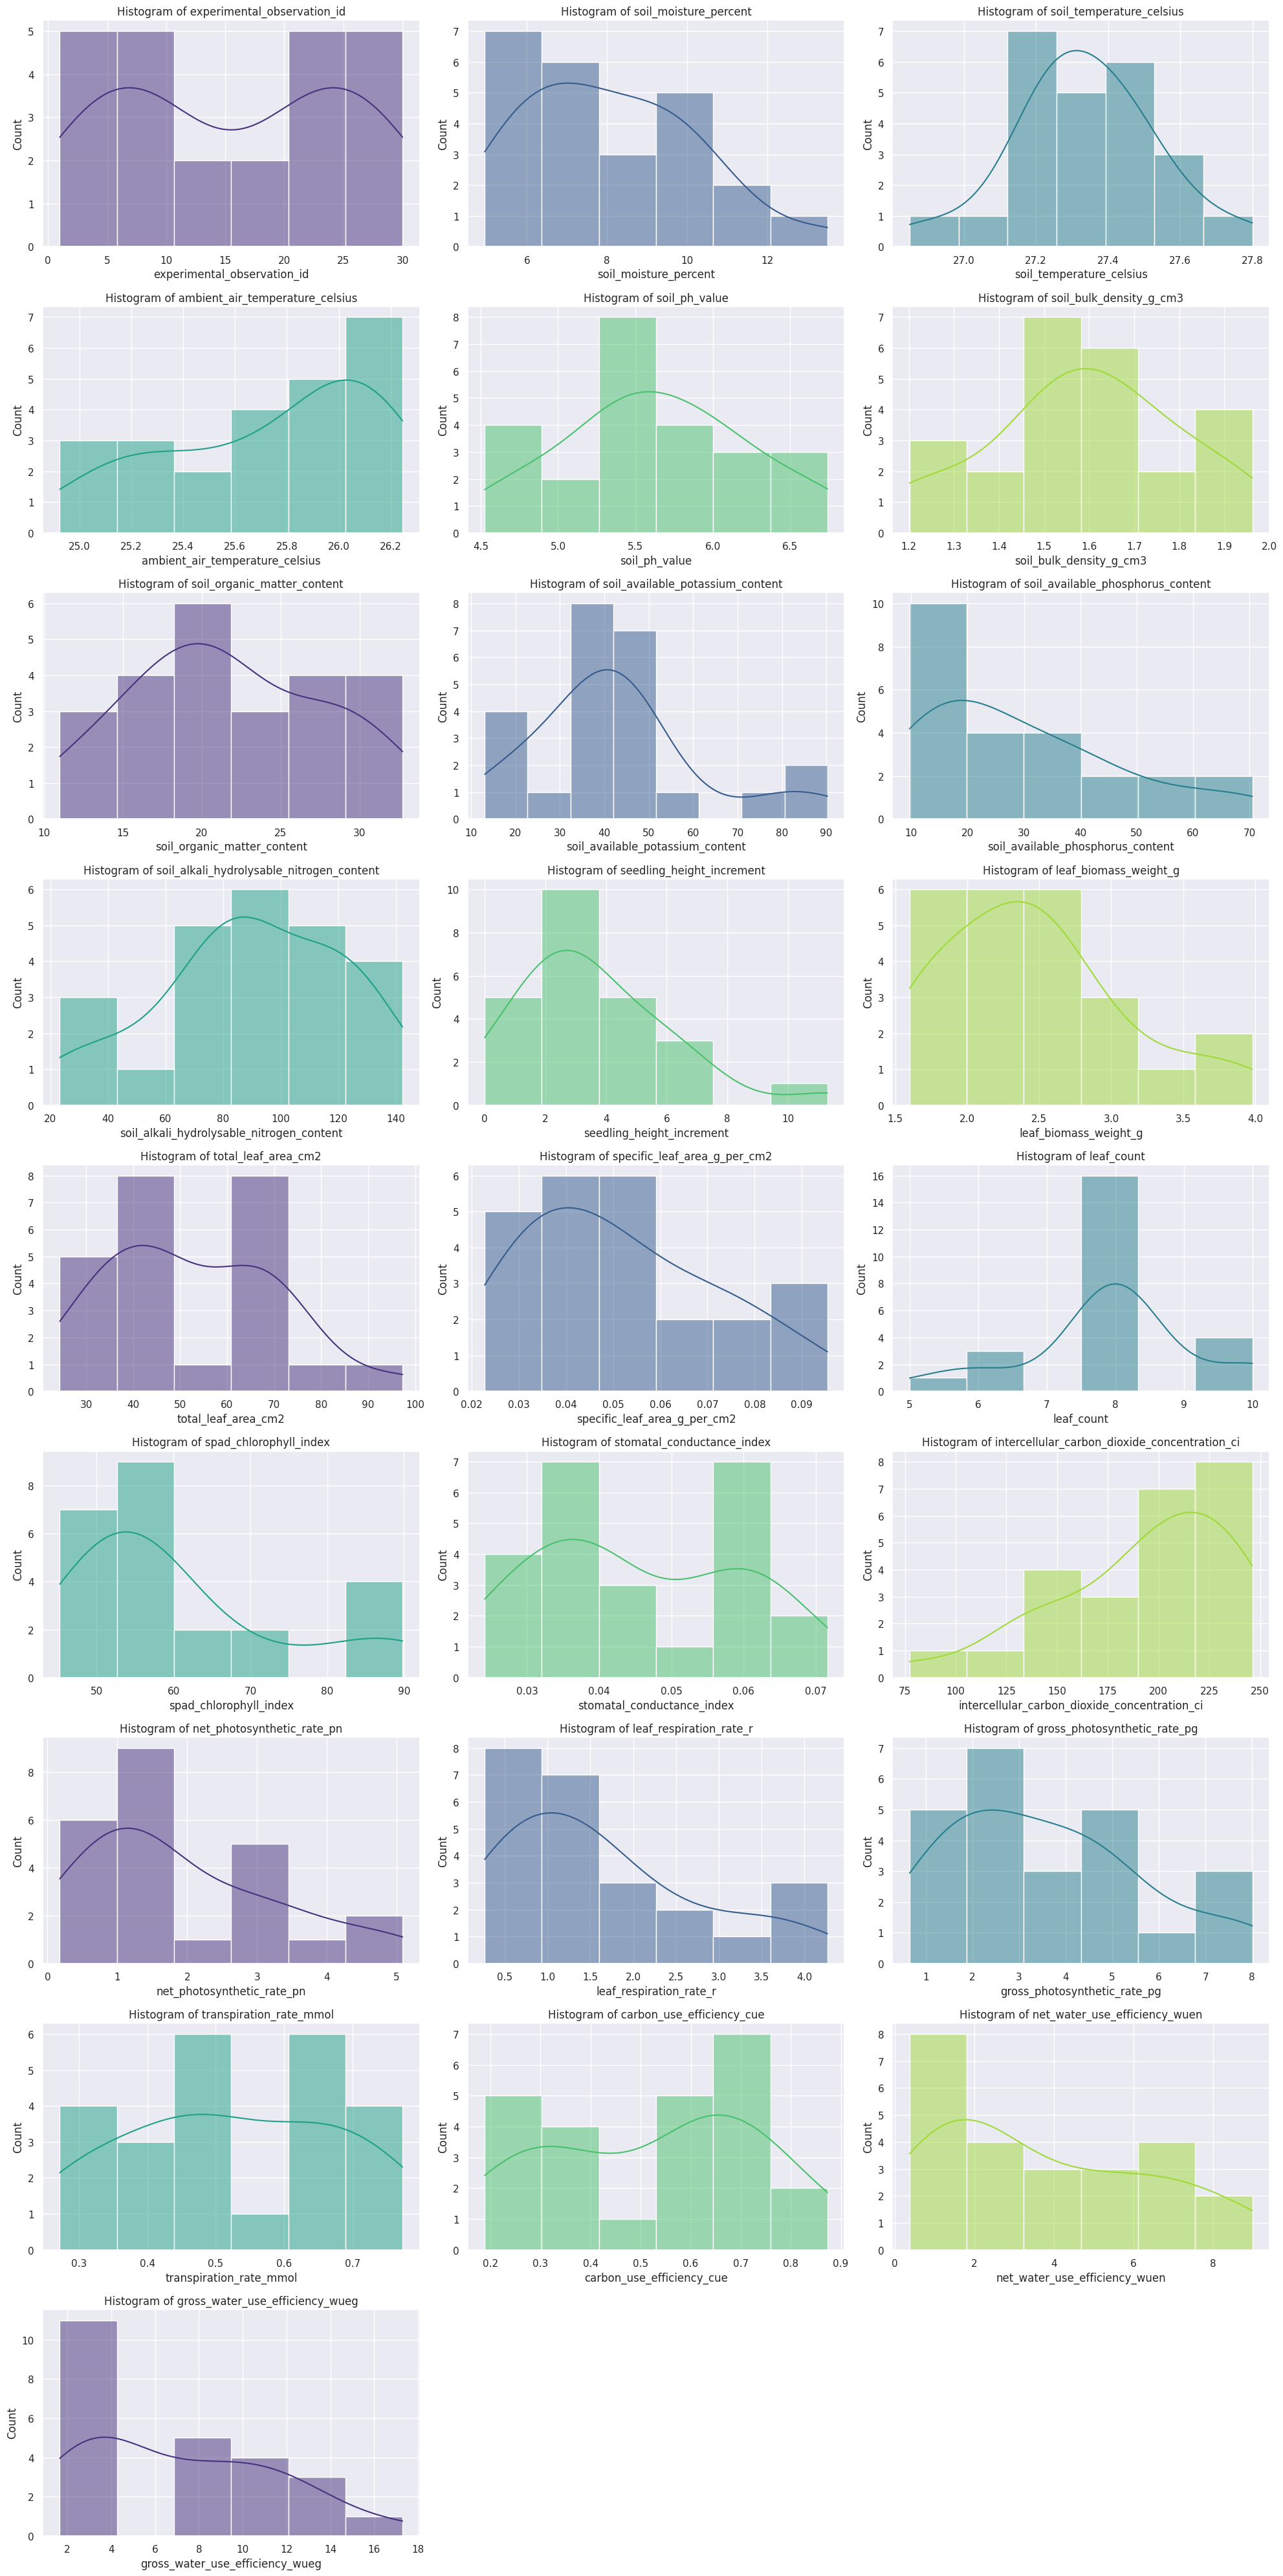

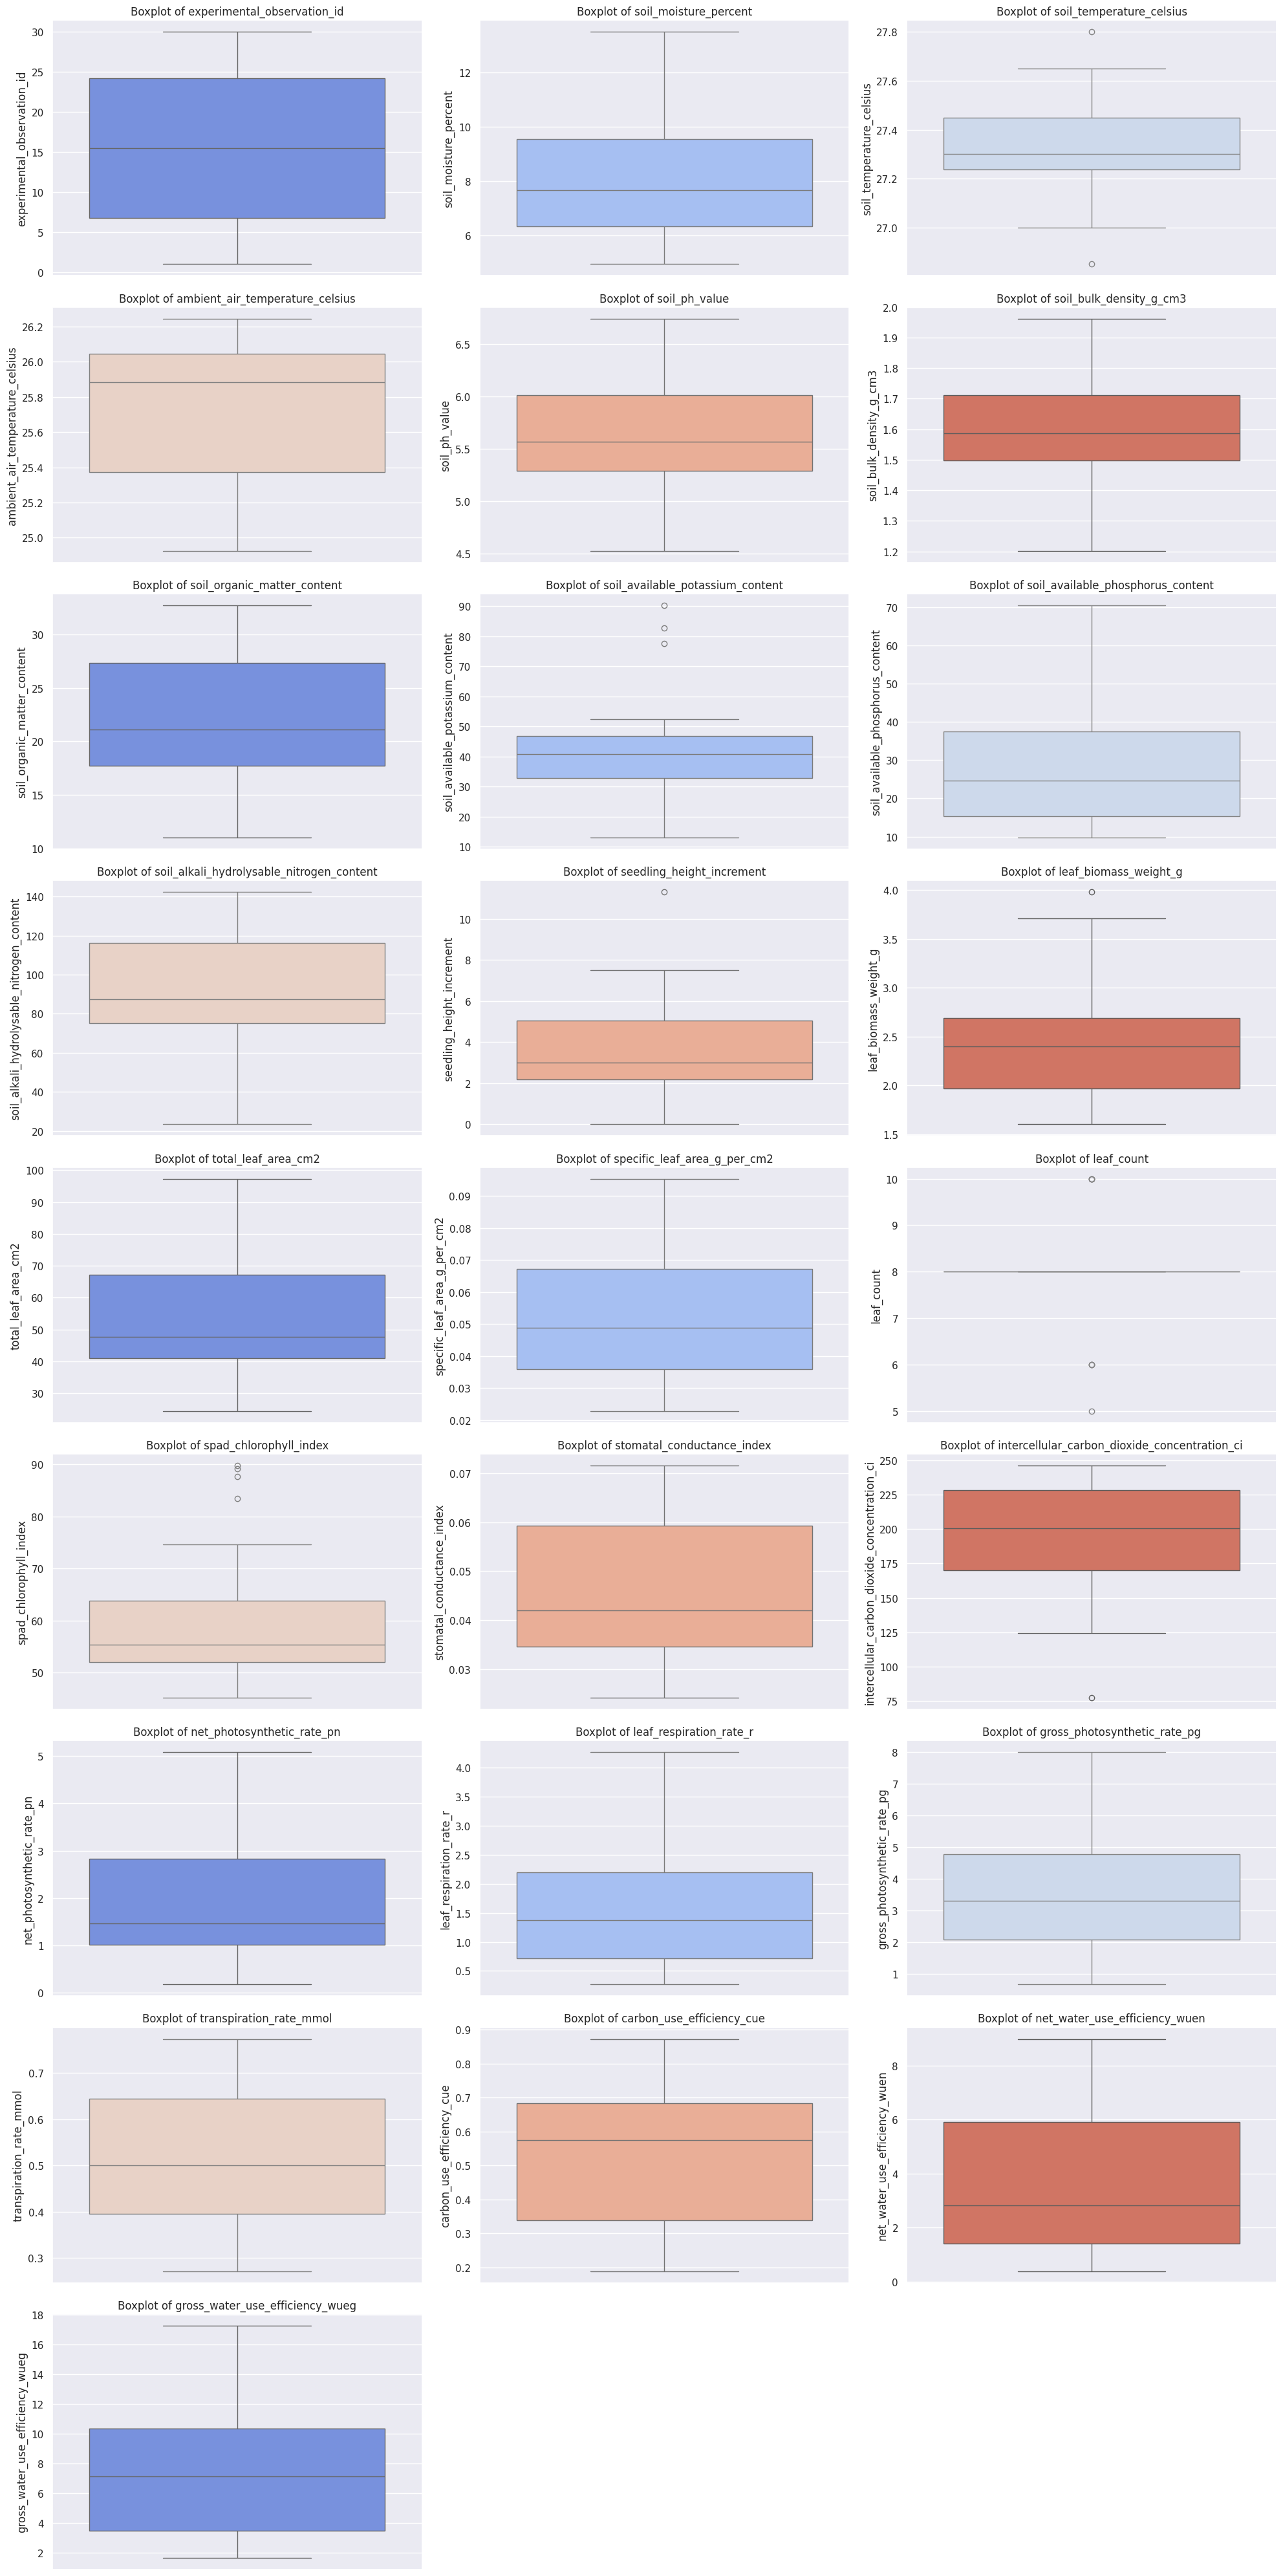

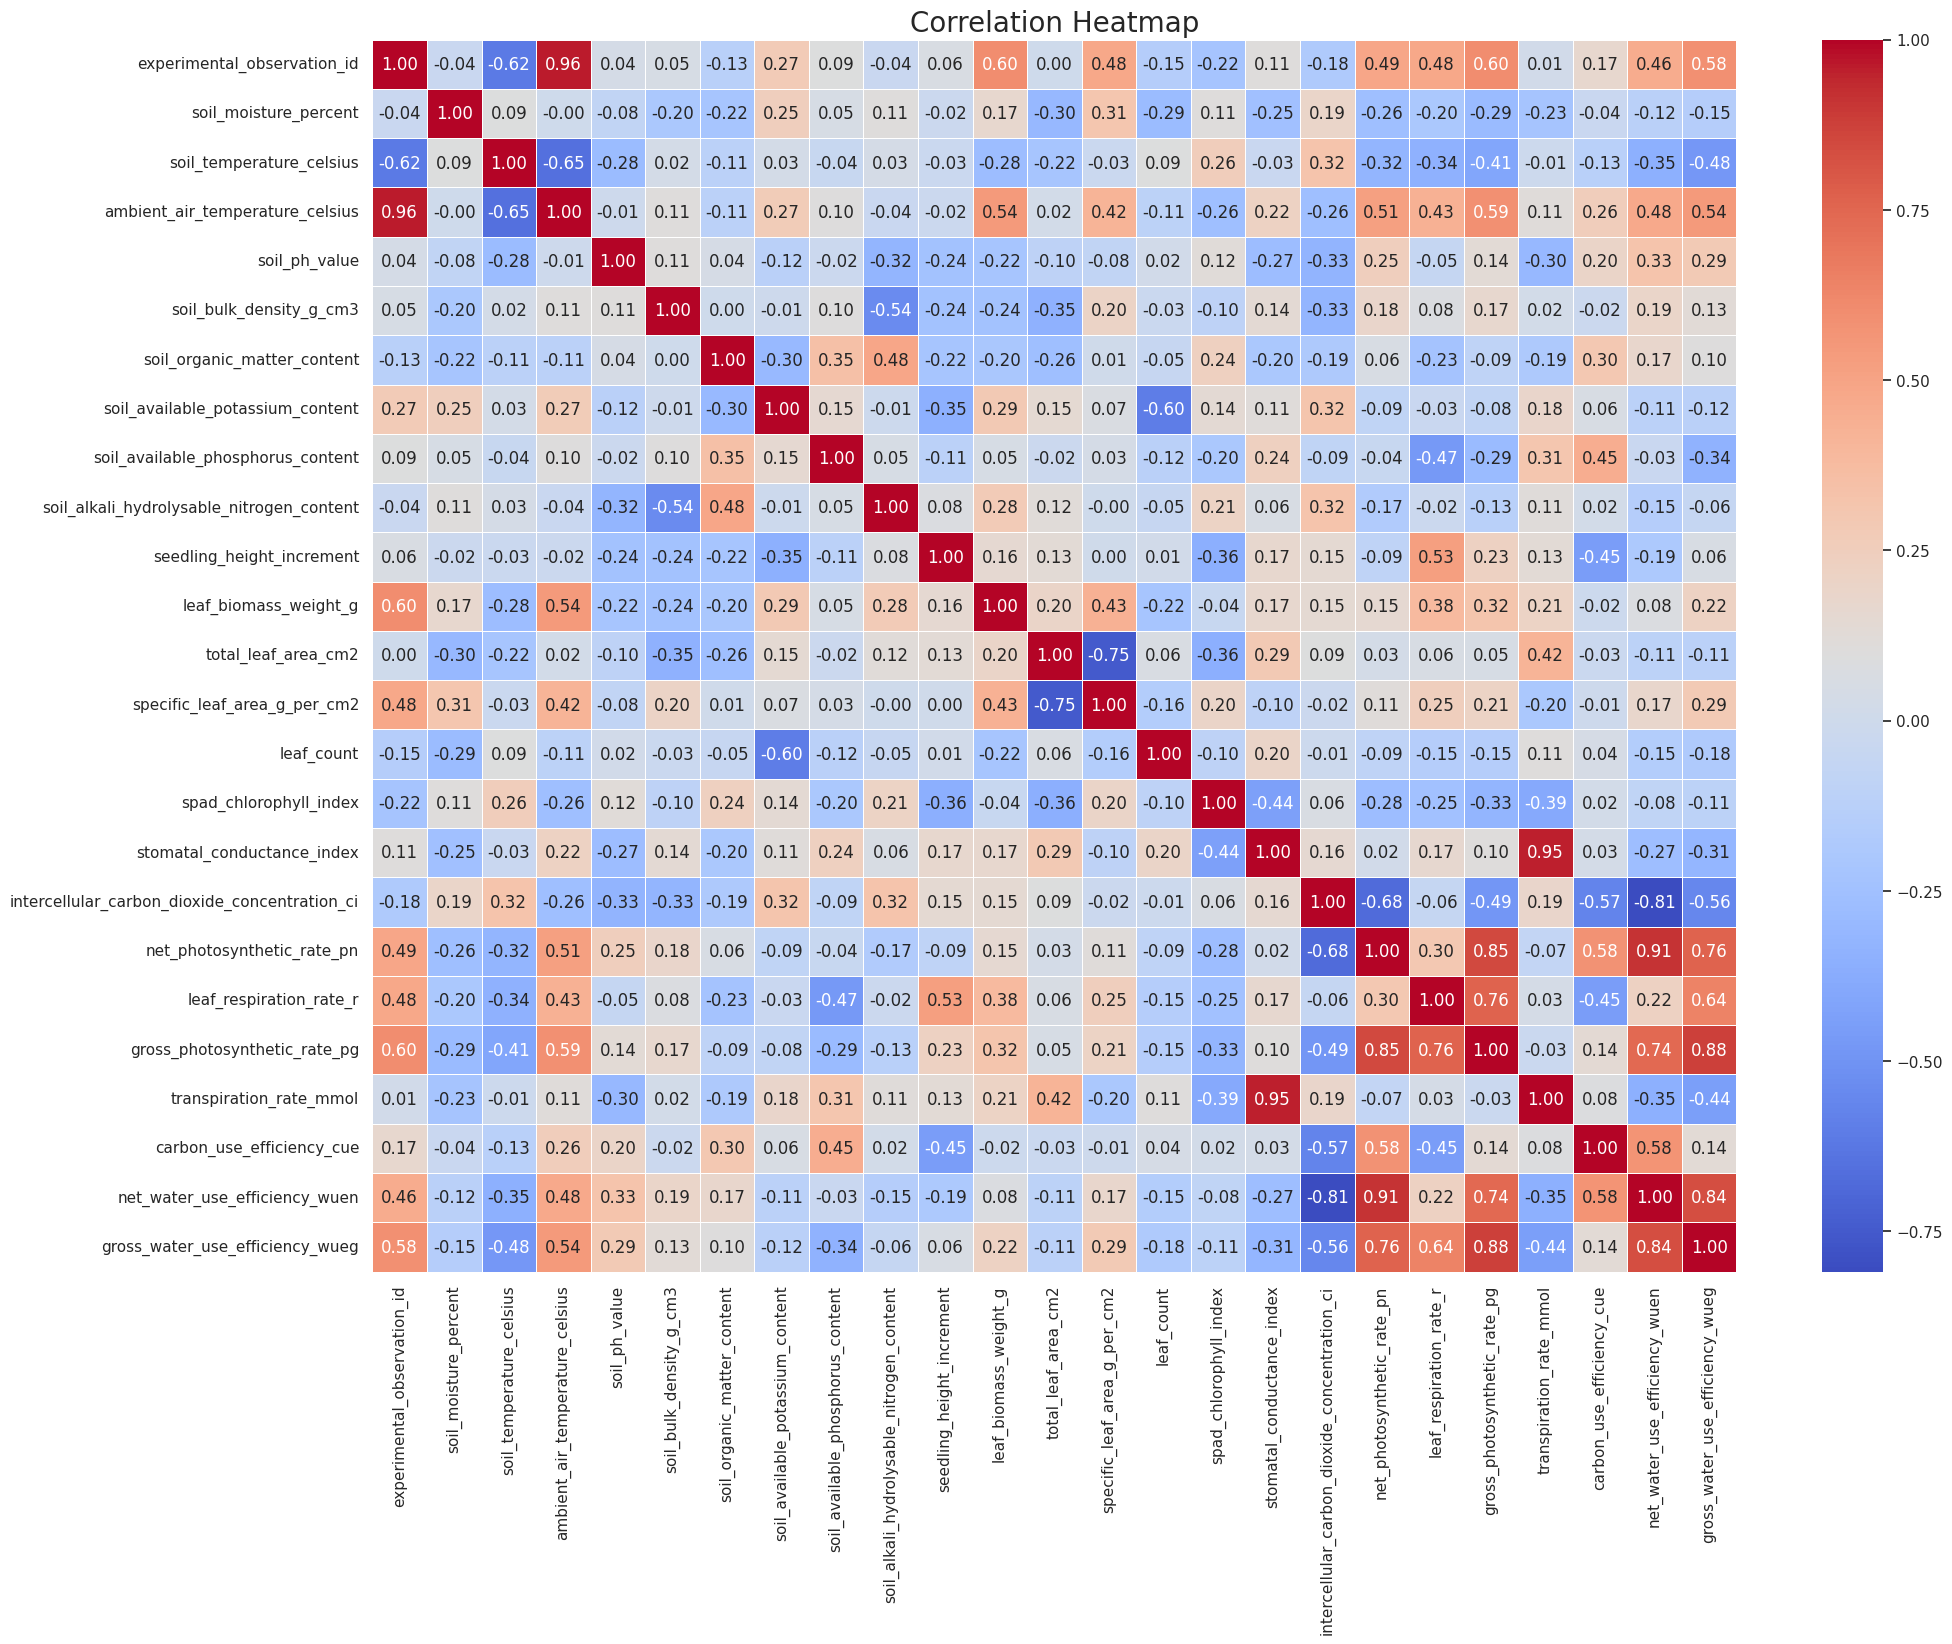

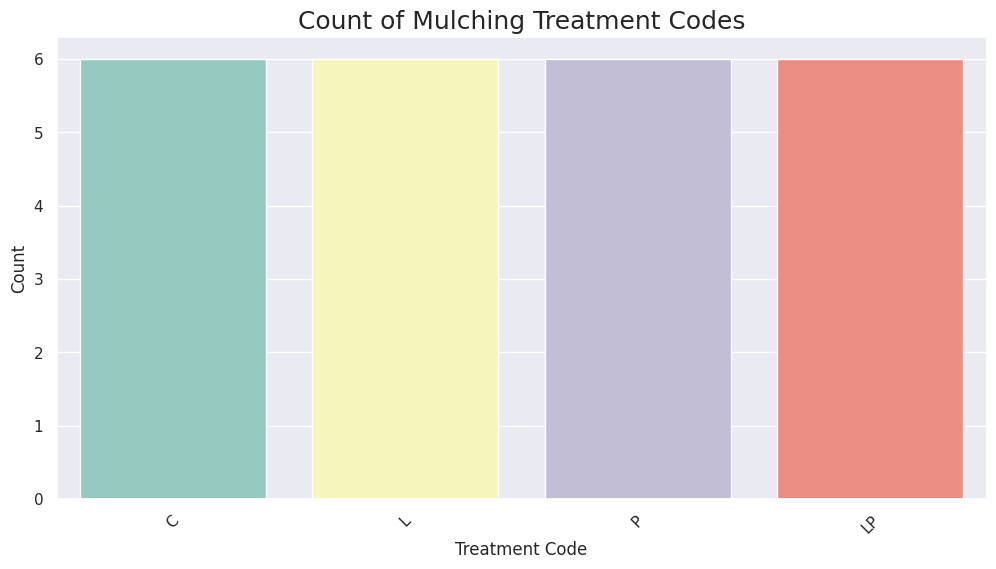

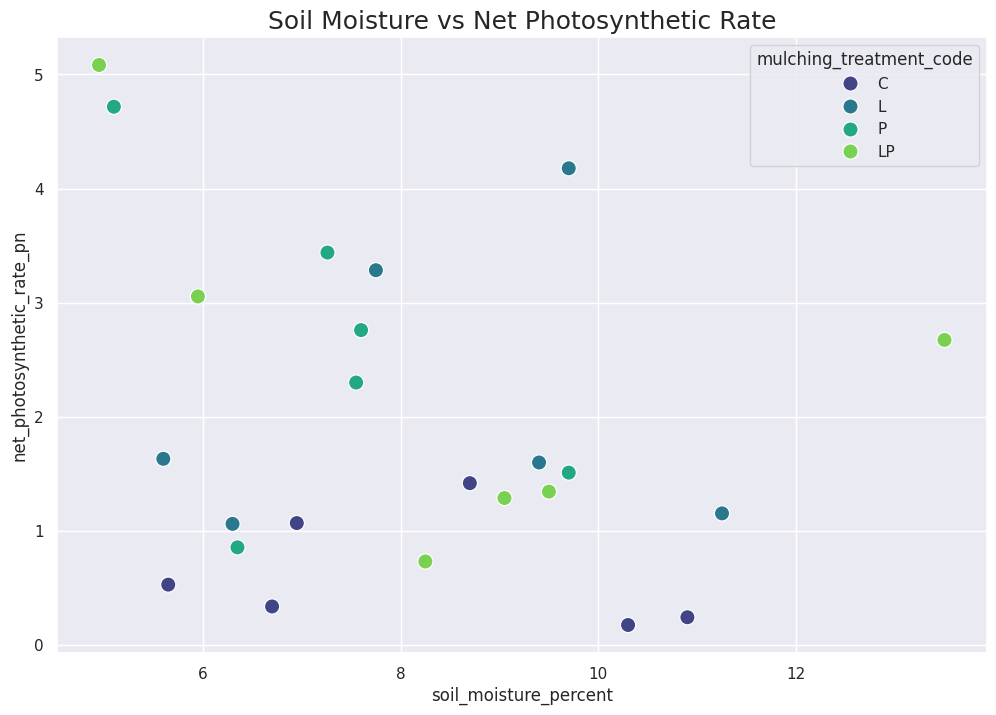

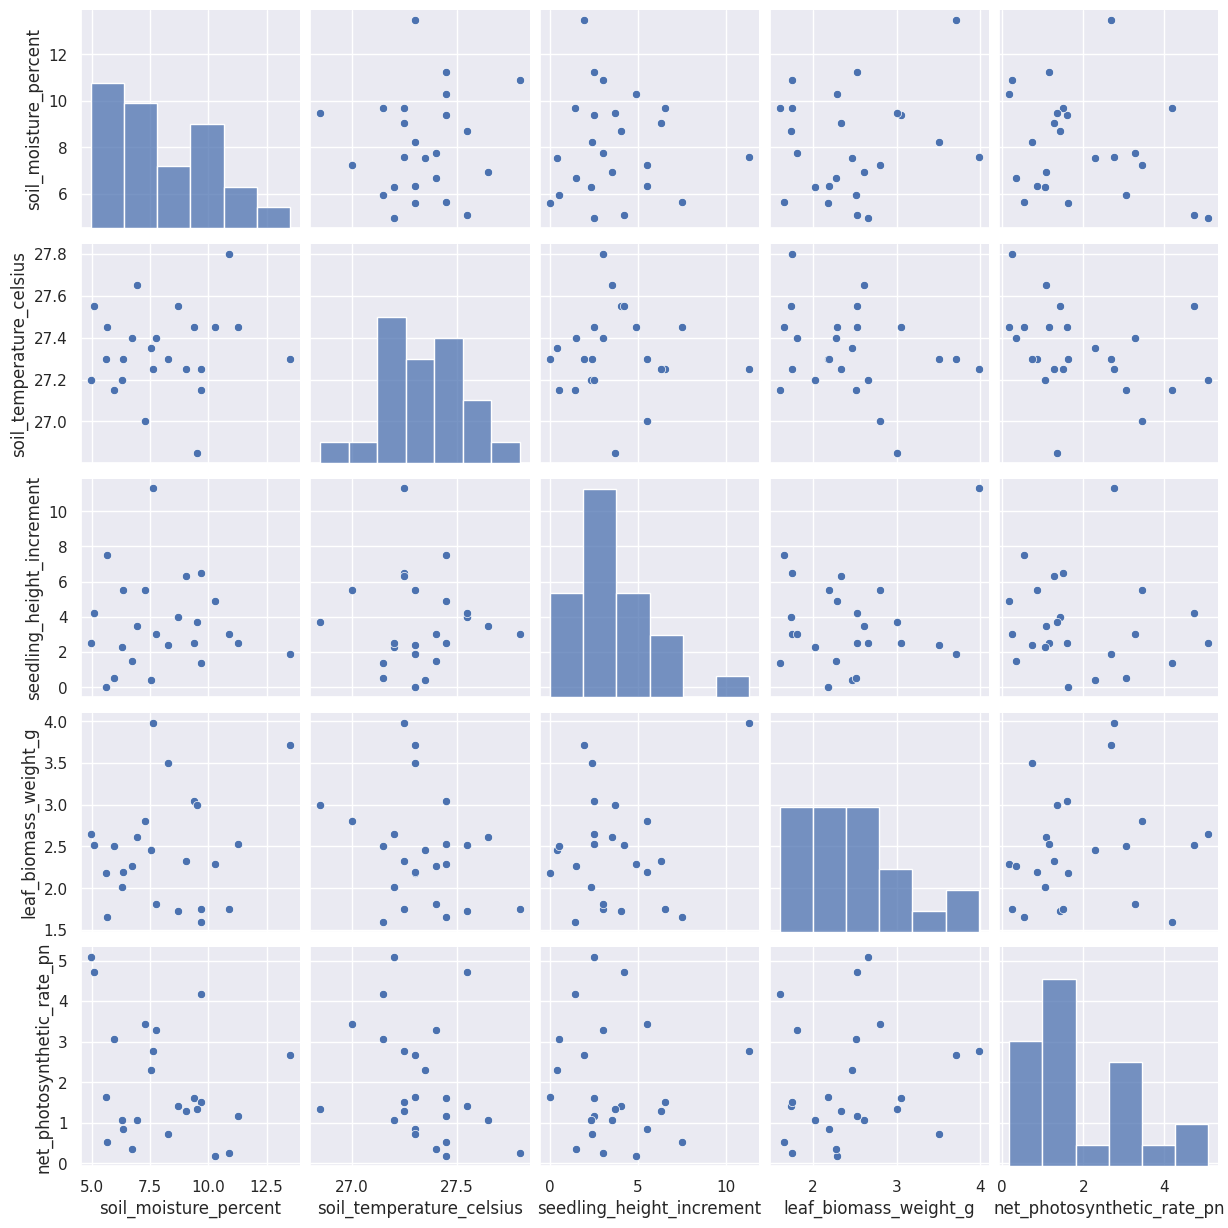

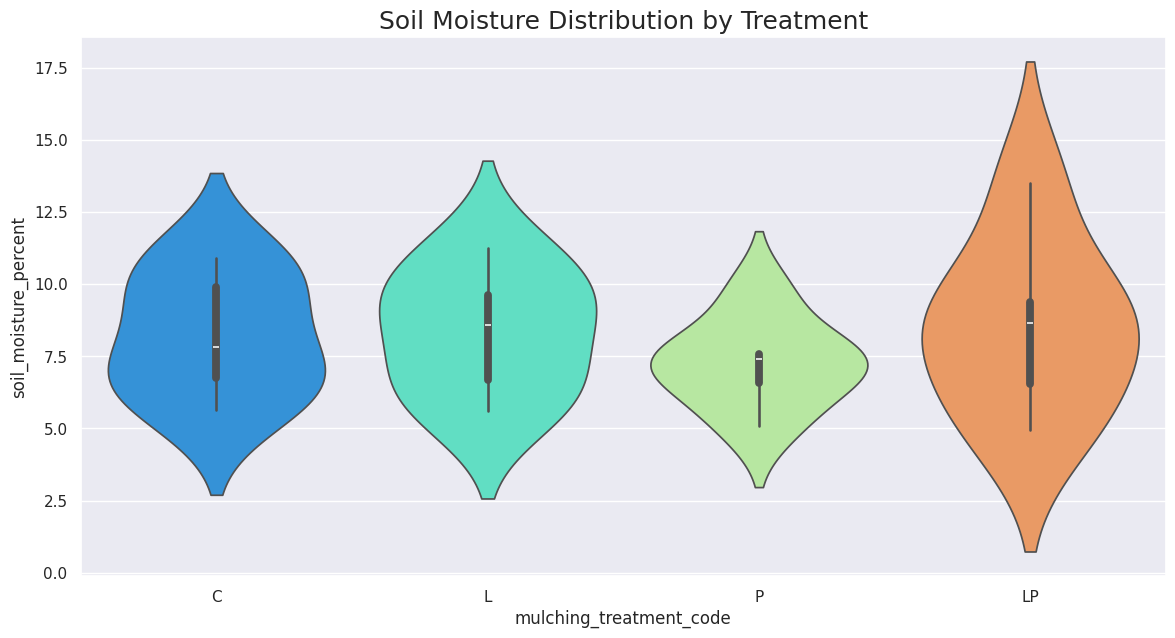

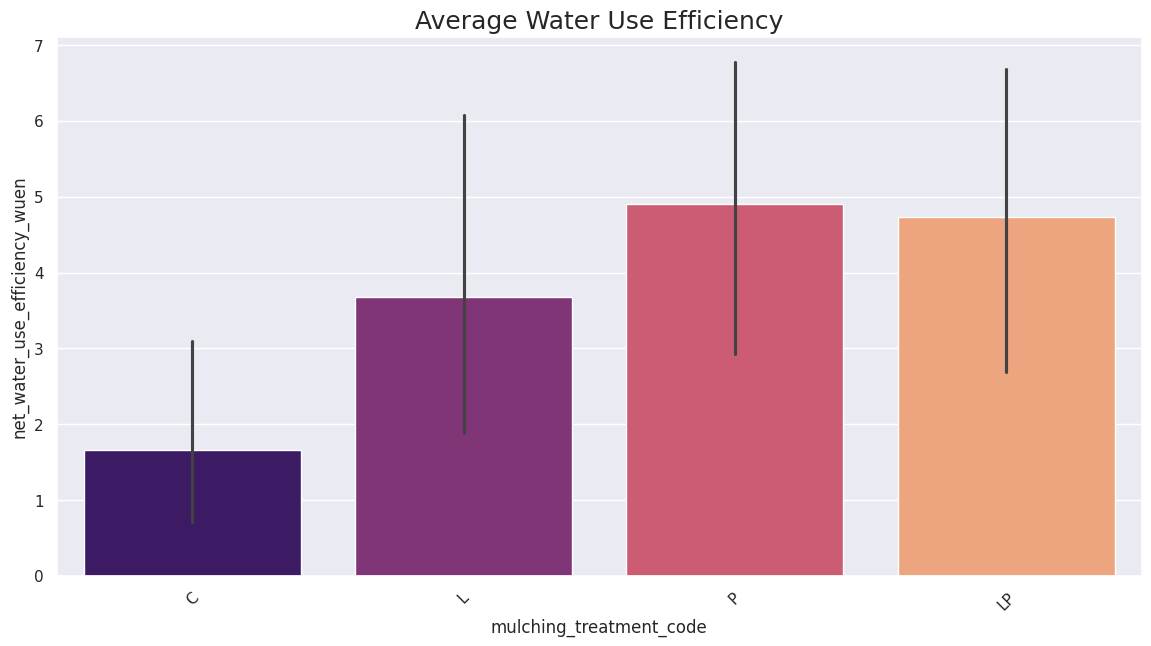

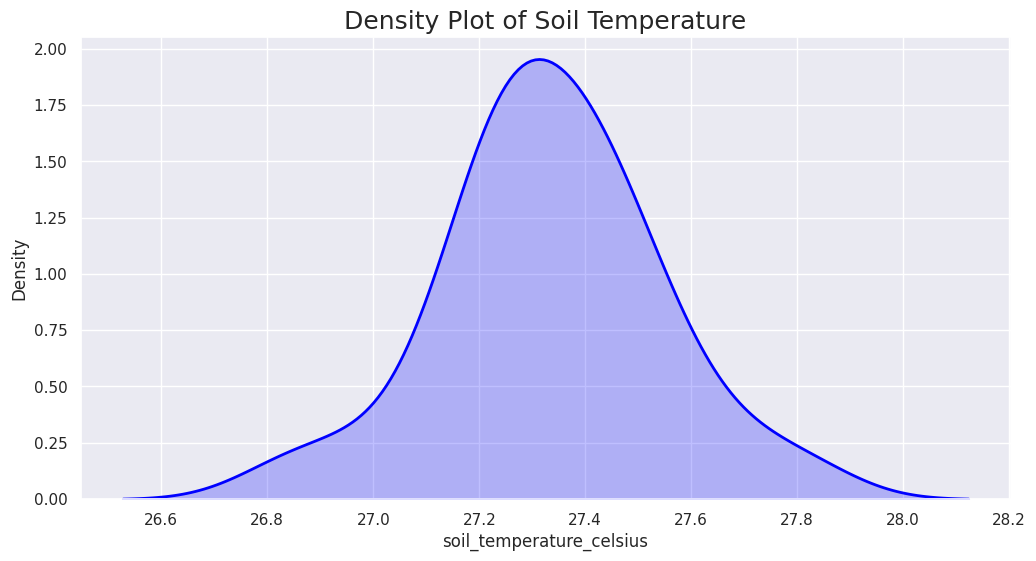

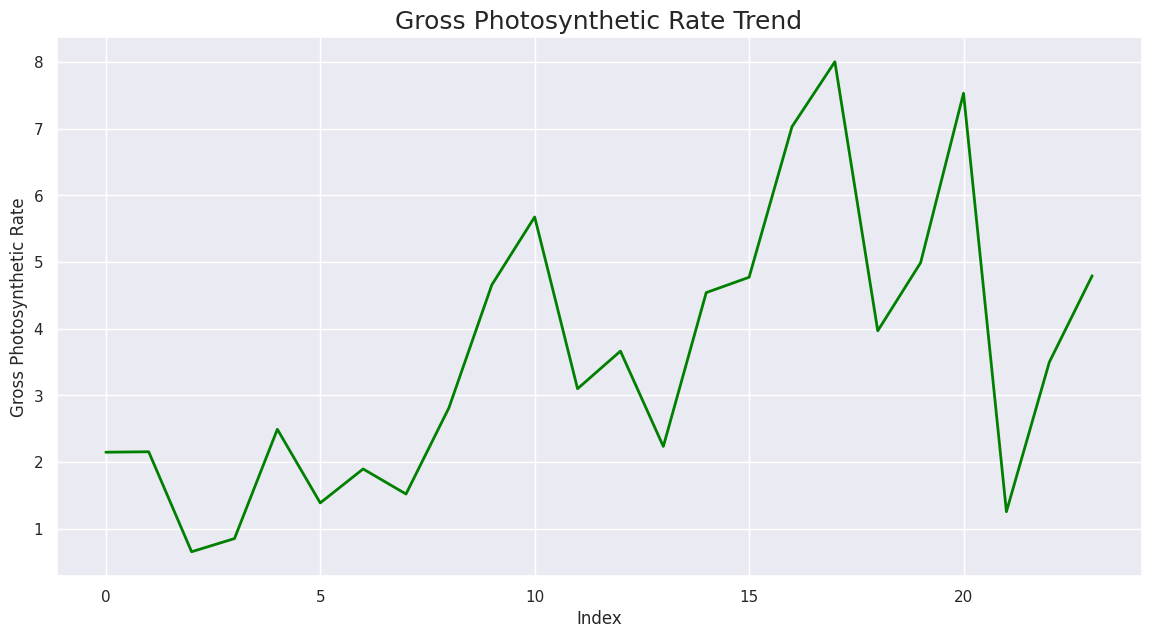

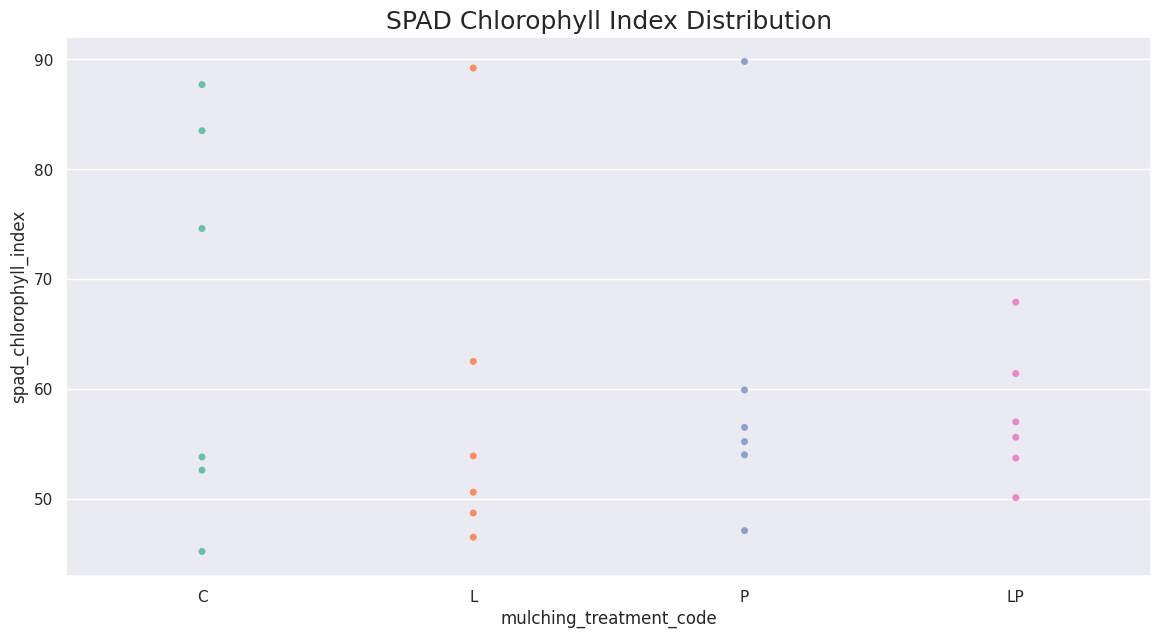

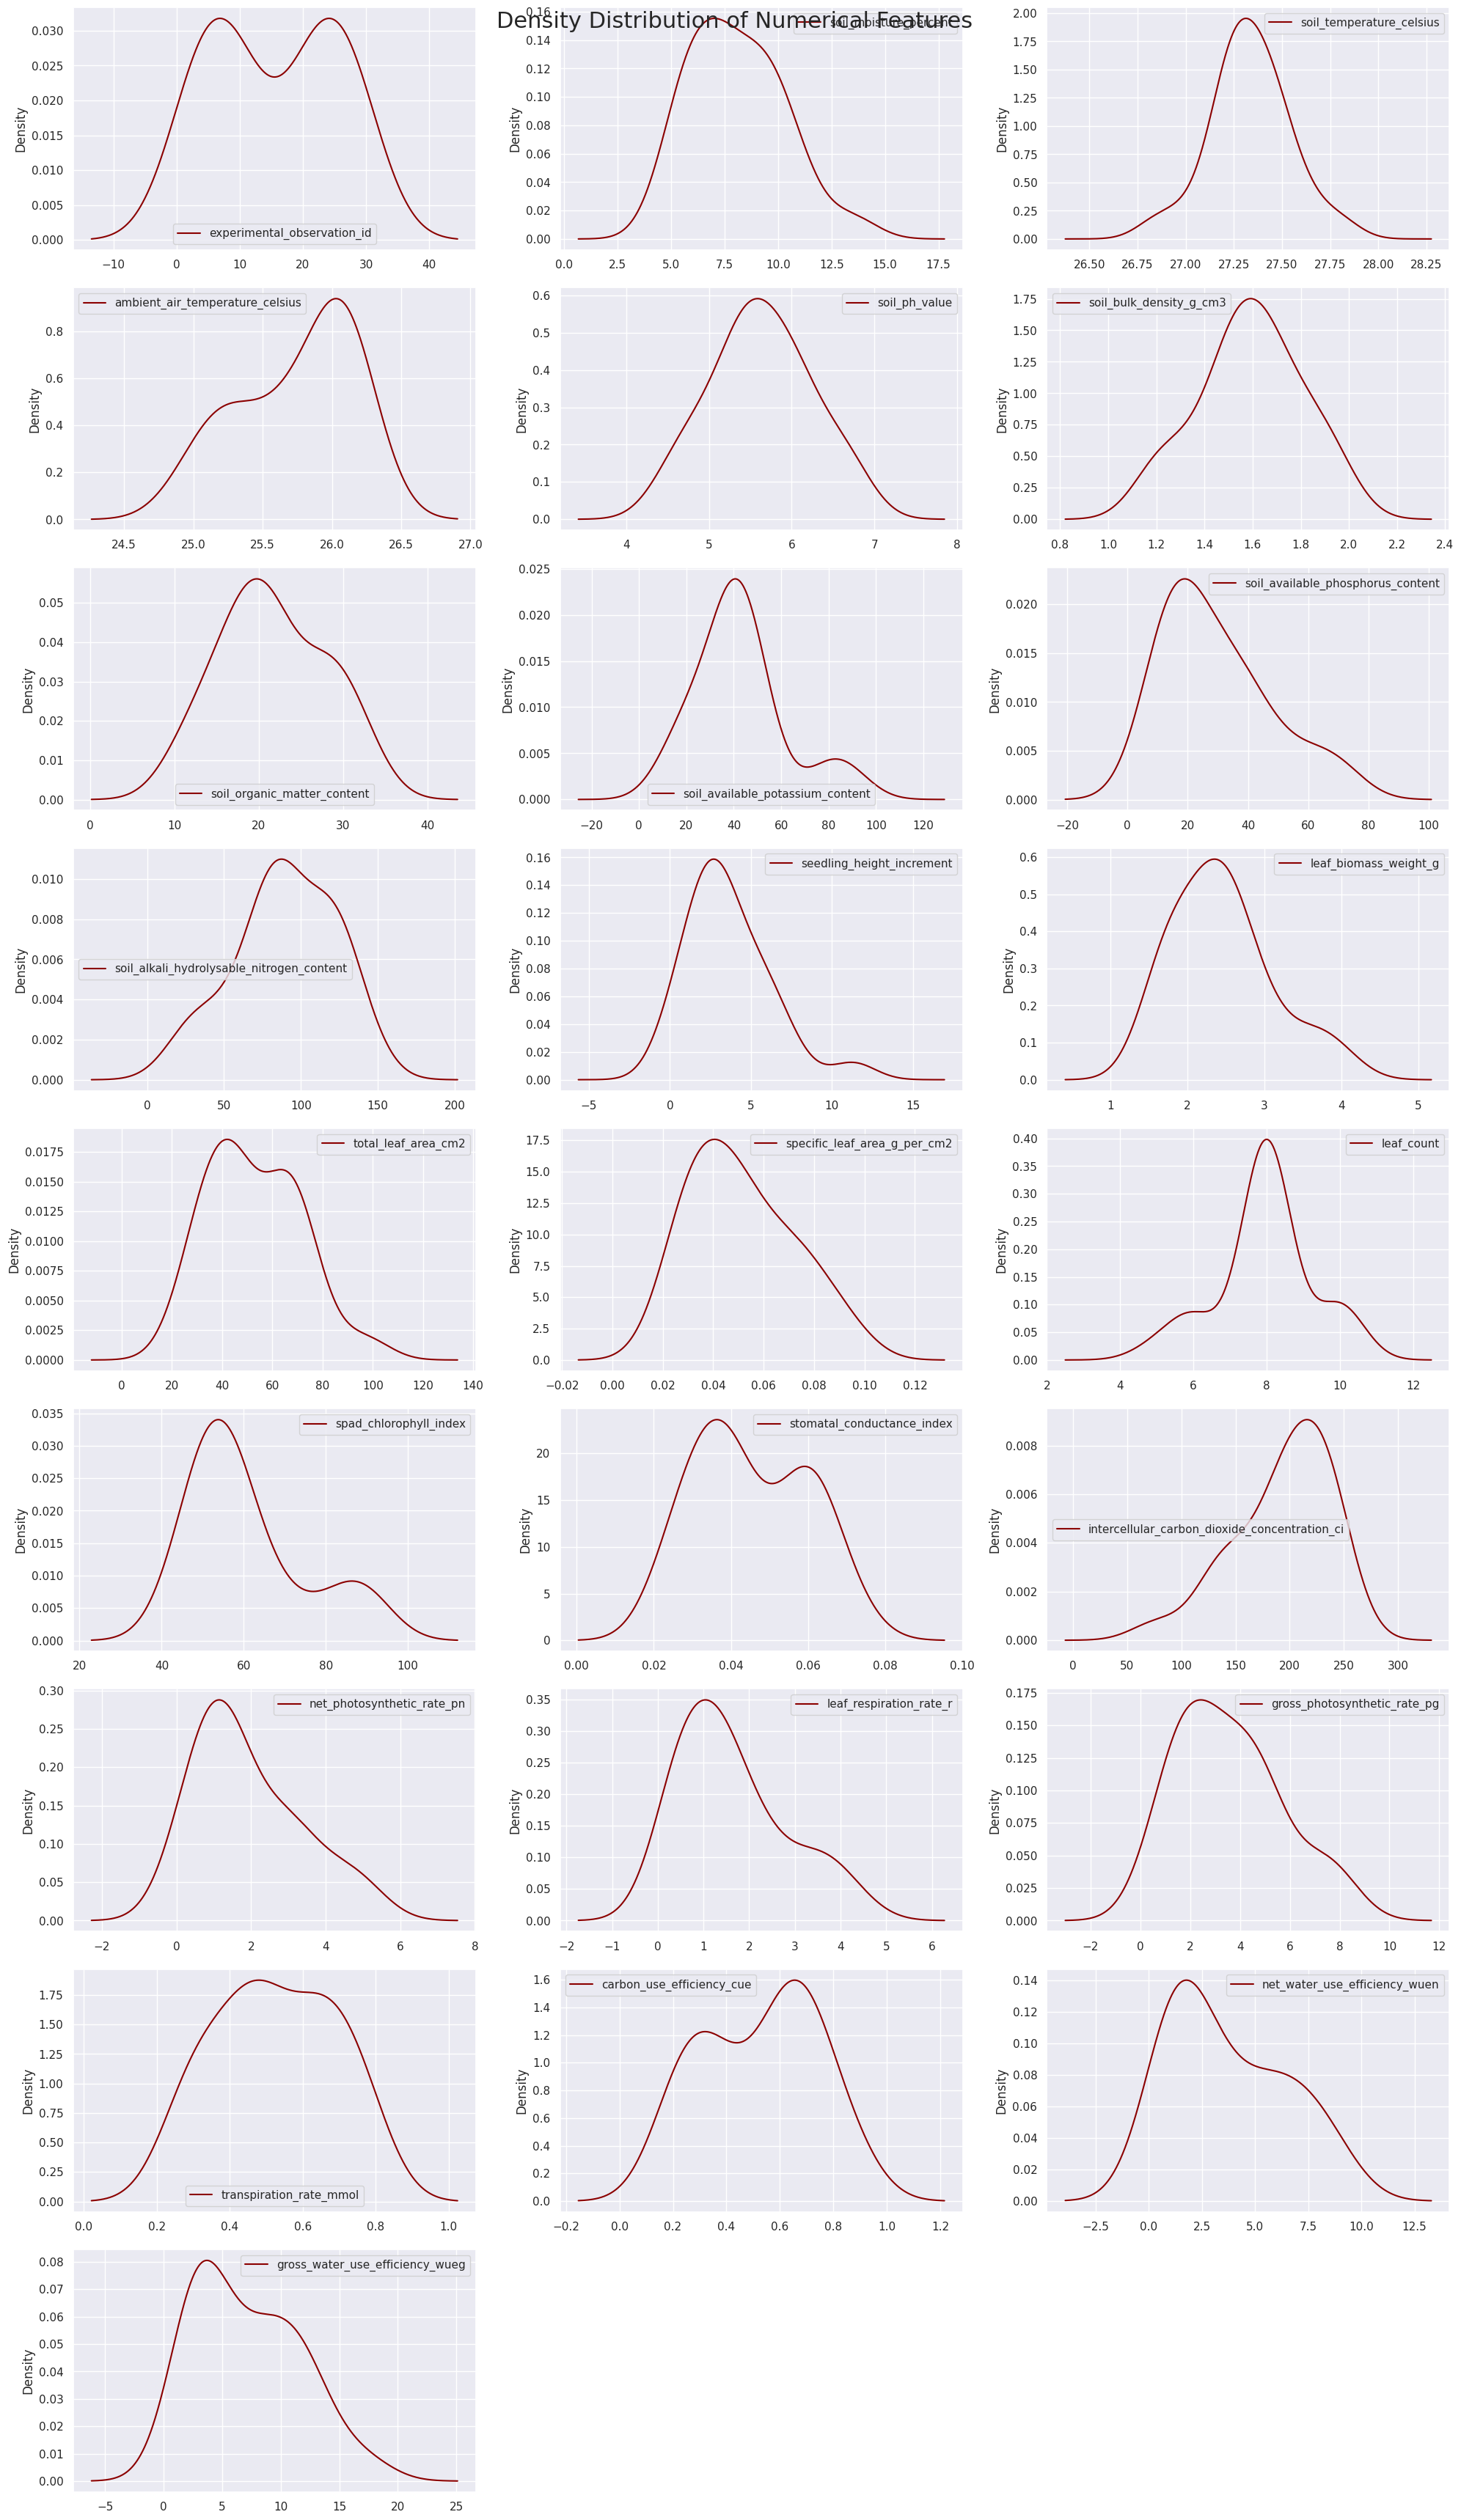

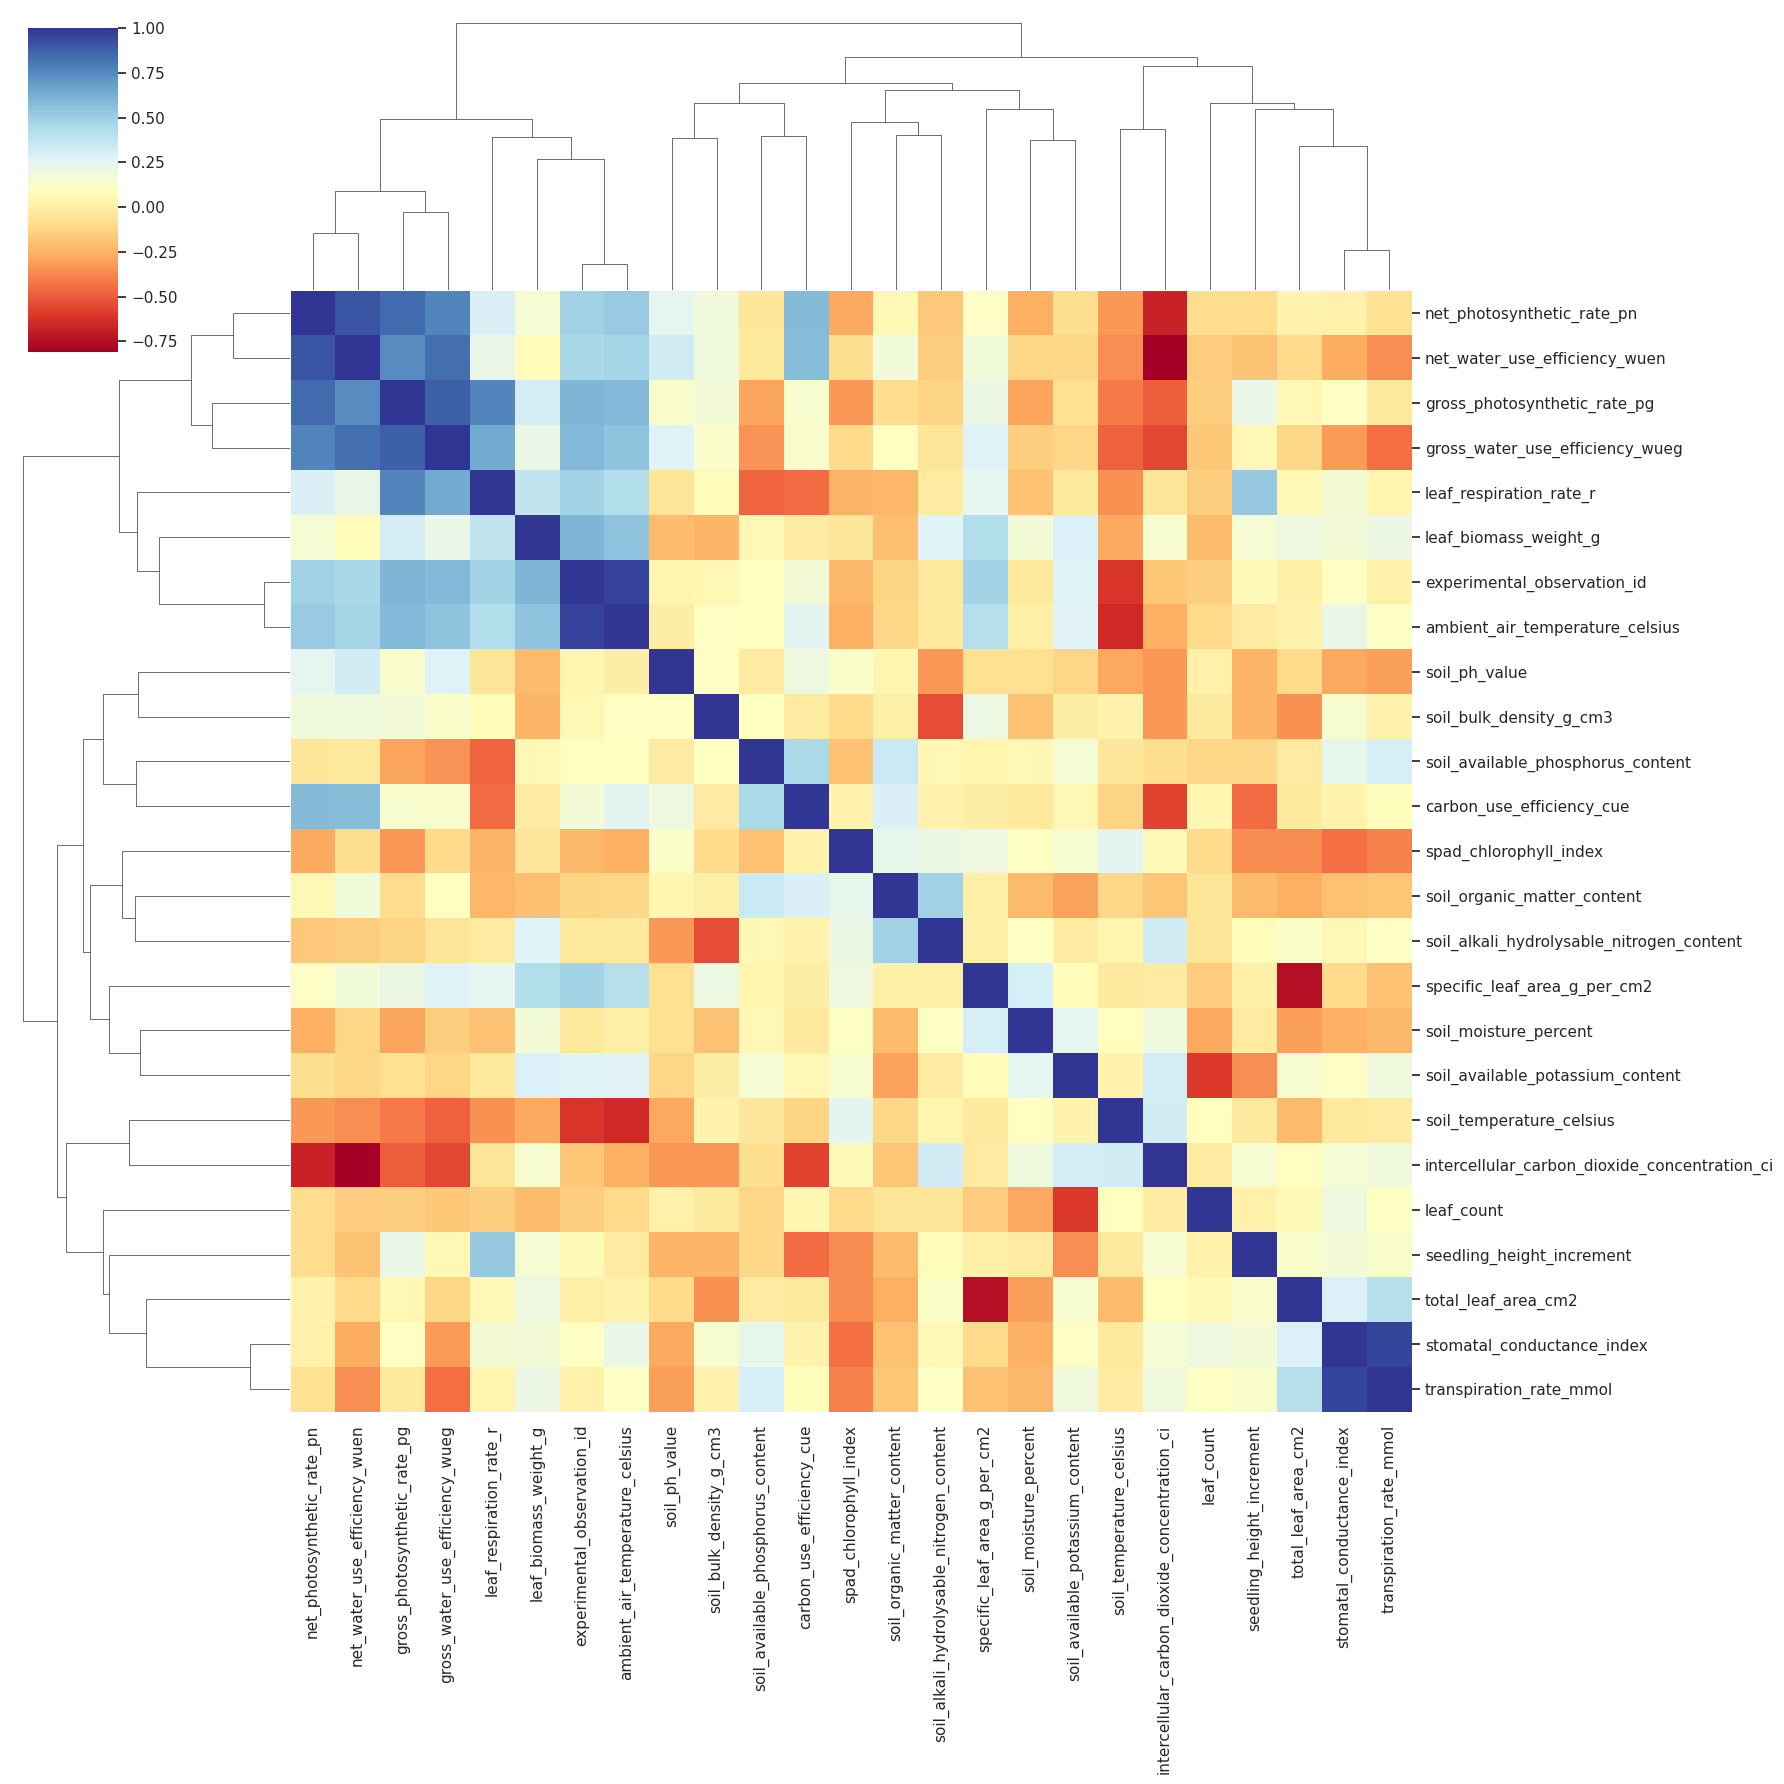

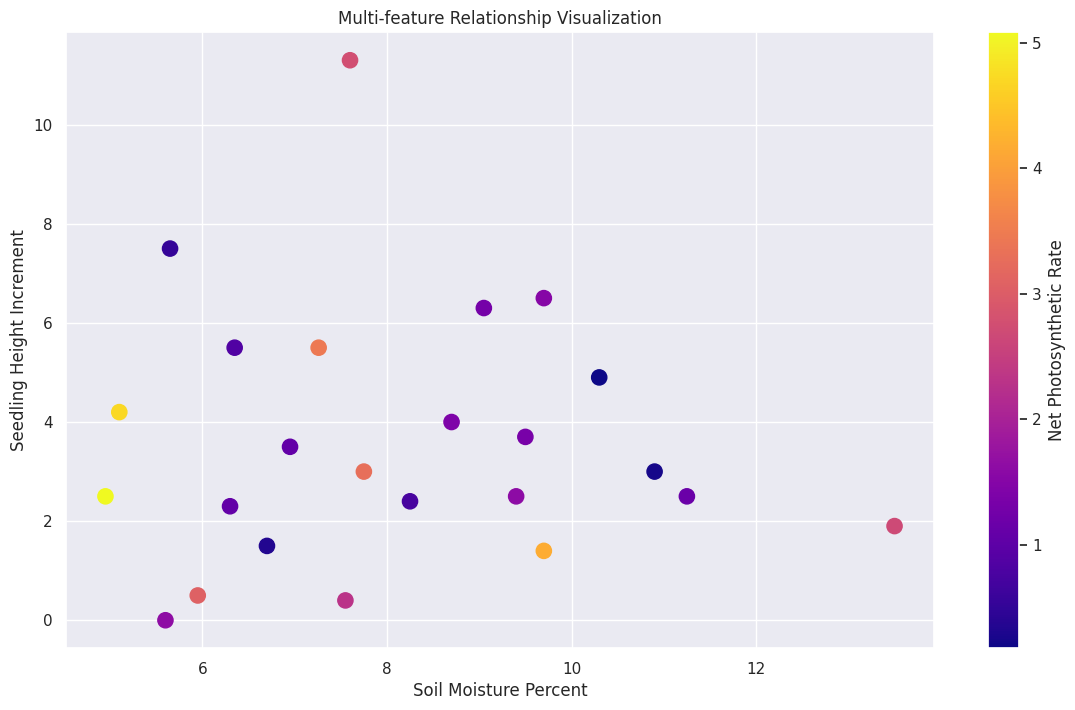

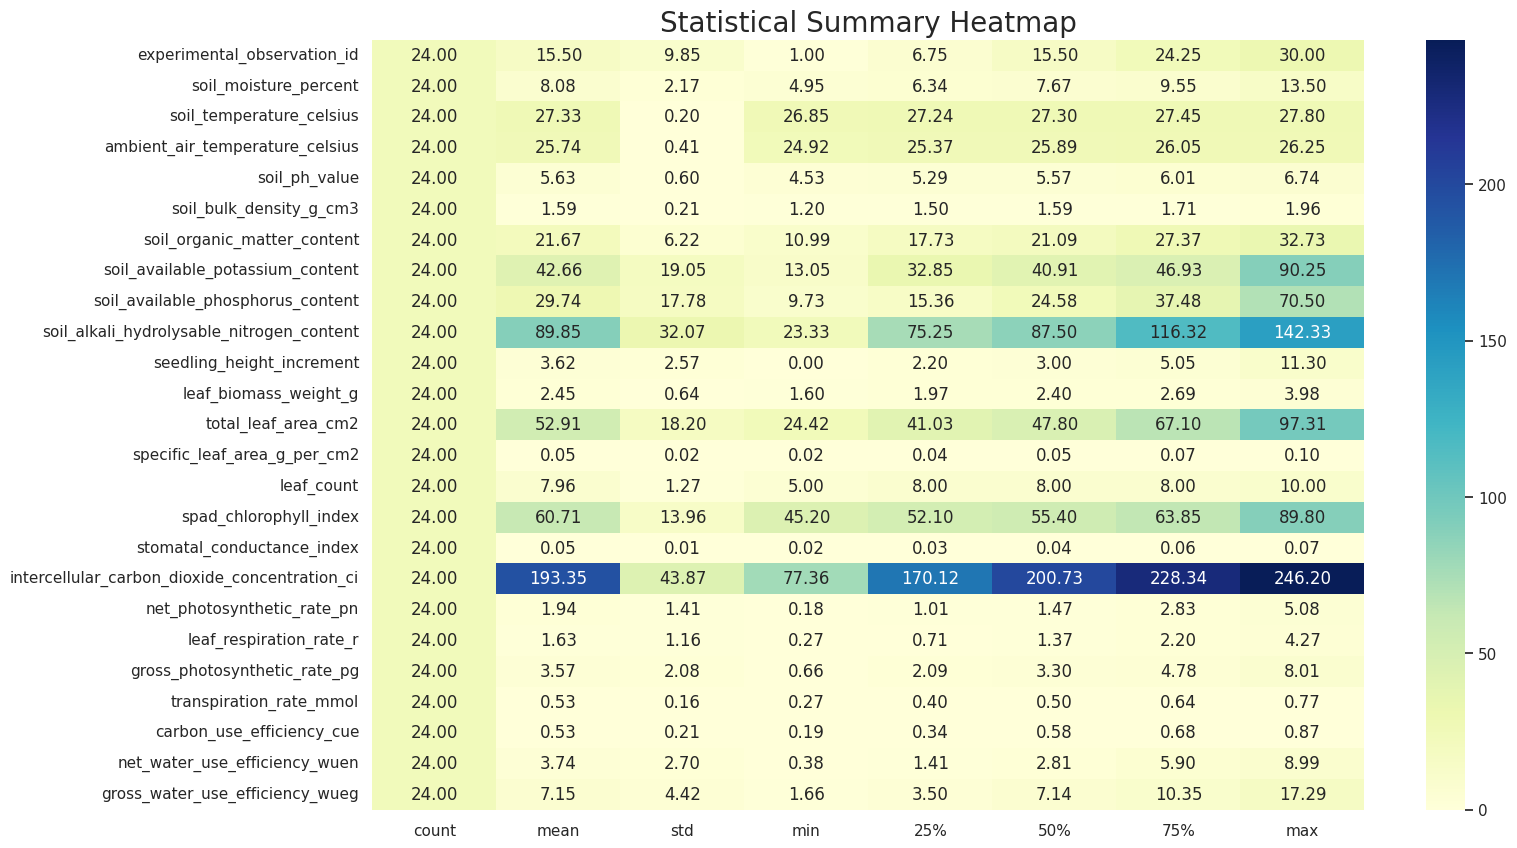


All visualizations completed successfully.


In [13]:
plt.style.use('ggplot')
sns.set(font_scale=1.0)

# --------------------------------------------
# DIFFERENT COLOR PALETTES
# --------------------------------------------
palette1 = sns.color_palette("viridis")
palette2 = sns.color_palette("coolwarm")
palette3 = sns.color_palette("Set2")
palette4 = sns.color_palette("Spectral")
palette5 = sns.color_palette("husl")

# ============================================
# 1. HISTOGRAMS FOR NUMERICAL FEATURES
# ============================================

numerical_cols = df.select_dtypes(include=np.number).columns

fig, axes = plt.subplots(len(numerical_cols)//3 + 1, 3, figsize=(20, 40))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        color=palette1[i % len(palette1)],
        ax=axes[i]
    )
    axes[i].set_title(f'Histogram of {col}', fontsize=12)

# Remove empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# ============================================
# 2. BOXPLOT VISUALIZATION
# ============================================

fig, axes = plt.subplots(len(numerical_cols)//3 + 1, 3, figsize=(20, 40))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(
        y=df[col],
        color=palette2[i % len(palette2)],
        ax=axes[i]
    )
    axes[i].set_title(f'Boxplot of {col}')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# ============================================
# 3. CORRELATION HEATMAP
# ============================================

plt.figure(figsize=(22, 16))

corr = df[numerical_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

# ============================================
# 4. COUNT PLOT OF MULCHING TREATMENTS
# ============================================

plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x='mulching_treatment_code',
    palette='Set3'
)

plt.title("Count of Mulching Treatment Codes", fontsize=18)
plt.xlabel("Treatment Code")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# ============================================
# 5. SCATTERPLOT
# ============================================

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df,
    x='soil_moisture_percent',
    y='net_photosynthetic_rate_pn',
    hue='mulching_treatment_code',
    palette='viridis',
    s=120
)

plt.title("Soil Moisture vs Net Photosynthetic Rate", fontsize=18)
plt.show()

# ============================================
# 6. PAIRPLOT
# ============================================

selected_cols = [
    'soil_moisture_percent',
    'soil_temperature_celsius',
    'seedling_height_increment',
    'leaf_biomass_weight_g',
    'net_photosynthetic_rate_pn'
]

sns.pairplot(
    df[selected_cols],
    palette='husl'
)

plt.show()

# ============================================
# 7. VIOLIN PLOT
# ============================================

plt.figure(figsize=(14, 7))

sns.violinplot(
    data=df,
    x='mulching_treatment_code',
    y='soil_moisture_percent',
    palette='rainbow'
)

plt.title("Soil Moisture Distribution by Treatment", fontsize=18)
plt.show()

# ============================================
# 8. BARPLOT
# ============================================

plt.figure(figsize=(14, 7))

sns.barplot(
    data=df,
    x='mulching_treatment_code',
    y='net_water_use_efficiency_wuen',
    palette='magma'
)

plt.title("Average Water Use Efficiency", fontsize=18)
plt.xticks(rotation=45)
plt.show()

# ============================================
# 9. KDE PLOT
# ============================================

plt.figure(figsize=(12, 6))

sns.kdeplot(
    data=df,
    x='soil_temperature_celsius',
    fill=True,
    color='blue',
    linewidth=2
)

plt.title("Density Plot of Soil Temperature", fontsize=18)
plt.show()

# ============================================
# 10. LINE PLOT
# ============================================

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=df,
    x=df.index,
    y='gross_photosynthetic_rate_pg',
    color='green',
    linewidth=2
)

plt.title("Gross Photosynthetic Rate Trend", fontsize=18)
plt.xlabel("Index")
plt.ylabel("Gross Photosynthetic Rate")
plt.show()

# ============================================
# 11. SWARM PLOT
# ============================================

plt.figure(figsize=(14, 7))

sns.swarmplot(
    data=df,
    x='mulching_treatment_code',
    y='spad_chlorophyll_index',
    palette='Set2'
)

plt.title("SPAD Chlorophyll Index Distribution", fontsize=18)
plt.show()

# ============================================
# 12. FEATURE DISTRIBUTION GRID
# ============================================

df[numerical_cols].plot(
    kind='density',
    subplots=True,
    layout=(9, 3),
    figsize=(20, 35),
    sharex=False,
    color='darkred'
)

plt.suptitle("Density Distribution of Numerical Features", fontsize=22)
plt.tight_layout()
plt.show()

# ============================================
# 13. ADVANCED CLUSTER MAP
# ============================================

sns.clustermap(
    corr,
    cmap='RdYlBu',
    figsize=(18, 18),
    annot=False
)

plt.show()

# ============================================
# 14. MULTI FEATURE RELATIONSHIP
# ============================================

plt.figure(figsize=(14, 8))

scatter = plt.scatter(
    df['soil_moisture_percent'],
    df['seedling_height_increment'],
    c=df['net_photosynthetic_rate_pn'],
    cmap='plasma',
    s=120
)

plt.colorbar(scatter, label='Net Photosynthetic Rate')
plt.xlabel("Soil Moisture Percent")
plt.ylabel("Seedling Height Increment")
plt.title("Multi-feature Relationship Visualization")
plt.show()

# ============================================
# 15. FINAL SUMMARY VISUALIZATION
# ============================================

summary = df[numerical_cols].describe().T

plt.figure(figsize=(16, 10))

sns.heatmap(
    summary,
    annot=True,
    cmap='YlGnBu',
    fmt='.2f'
)

plt.title("Statistical Summary Heatmap", fontsize=20)
plt.show()

# ============================================
# END OF COMPLETE VISUALIZATION
# ============================================

print("\nAll visualizations completed successfully.")

## Feature engineering


Encoded Target Classes:
['C' 'L' 'LP' 'P']

Categorical Columns:
Index(['mulching_treatment_description'], dtype='object')

Training Shape : (19, 26)
Testing Shape  : (5, 26)

MODEL : Logistic Regression

Accuracy Score : 0.6000

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       0.50      1.00      0.67         1
           2       1.00      0.50      0.67         2
           3       0.00      0.00      0.00         1

    accuracy                           0.60         5
   macro avg       0.62      0.62      0.58         5
weighted avg       0.70      0.60      0.60         5



<Figure size 1200x800 with 0 Axes>

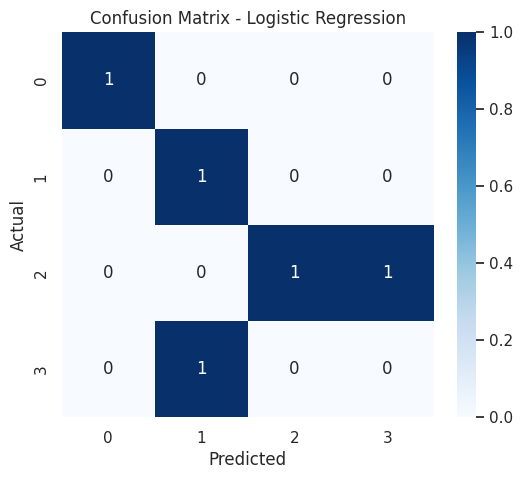

ROC-AUC Score : 0.7917

MODEL : Decision Tree

Accuracy Score : 1.0000

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         1

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



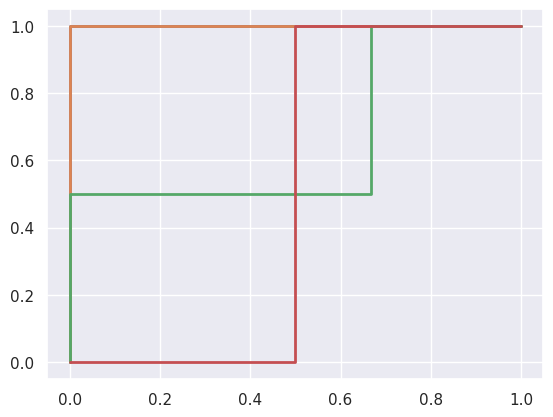

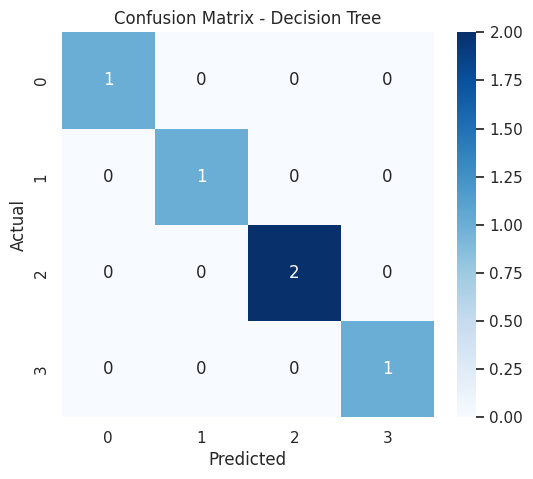

ROC-AUC Score : 1.0000

MODEL : Random Forest

Accuracy Score : 1.0000

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         1

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



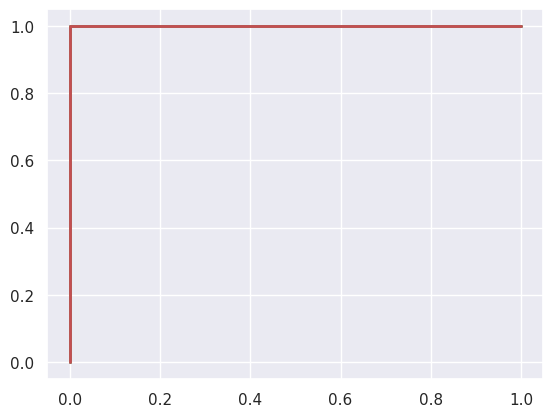

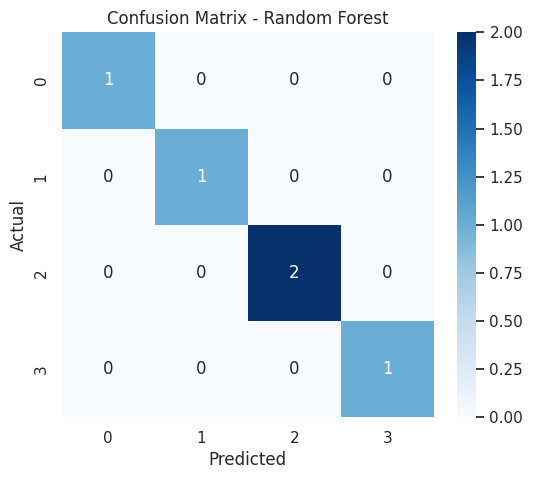

ROC-AUC Score : 1.0000

MODEL : Gradient Boosting

Accuracy Score : 1.0000

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         1

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



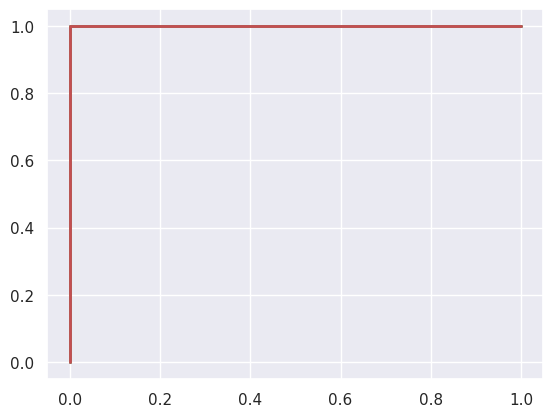

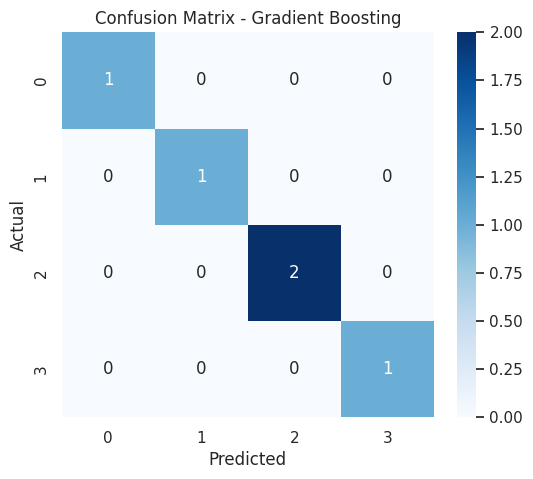

ROC-AUC Score : 1.0000

MODEL : Support Vector Machine

Accuracy Score : 0.4000

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       0.33      1.00      0.50         1
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         1

    accuracy                           0.40         5
   macro avg       0.33      0.50      0.38         5
weighted avg       0.27      0.40      0.30         5



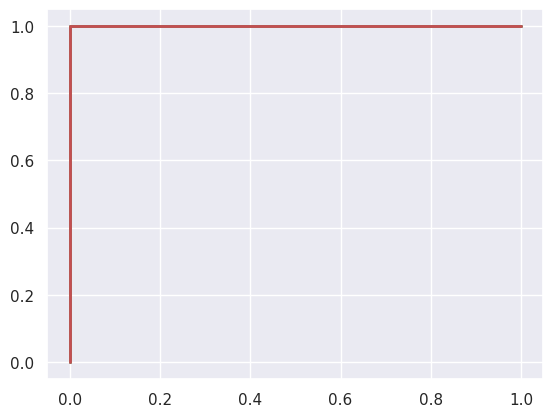

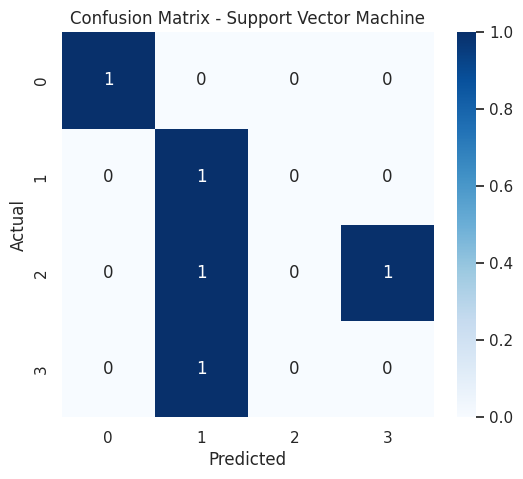

ROC-AUC Score : 0.7500

MODEL : K-Nearest Neighbors

Accuracy Score : 0.6000

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       0.50      1.00      0.67         1
           2       1.00      0.50      0.67         2
           3       0.00      0.00      0.00         1

    accuracy                           0.60         5
   macro avg       0.62      0.62      0.58         5
weighted avg       0.70      0.60      0.60         5



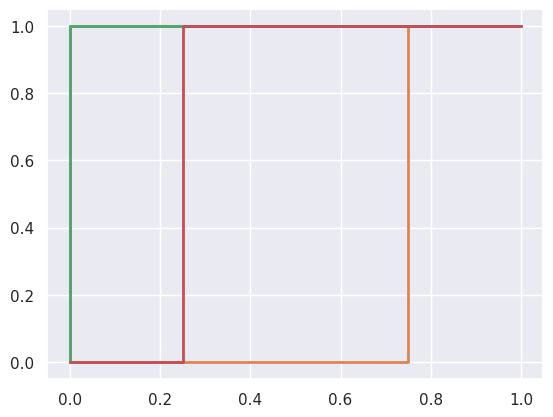

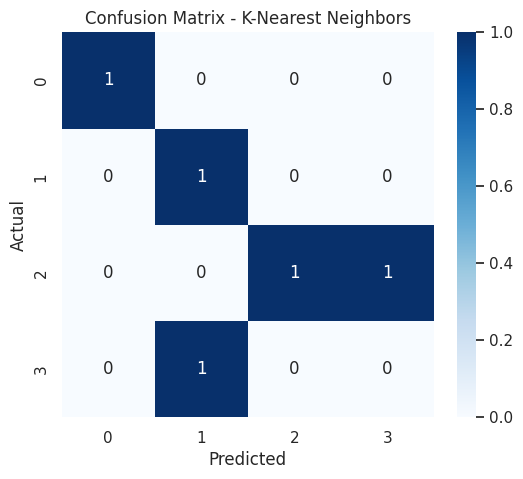

ROC-AUC Score : 0.7604

MODEL : Naive Bayes

Accuracy Score : 1.0000

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         1

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



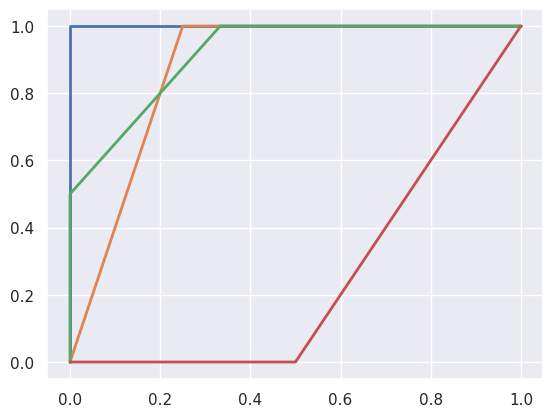

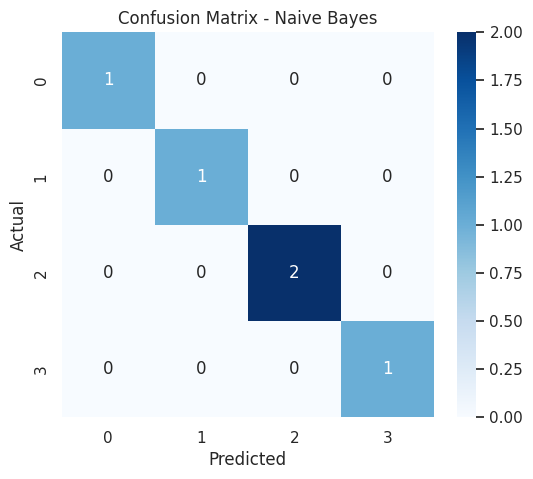

ROC-AUC Score : 1.0000


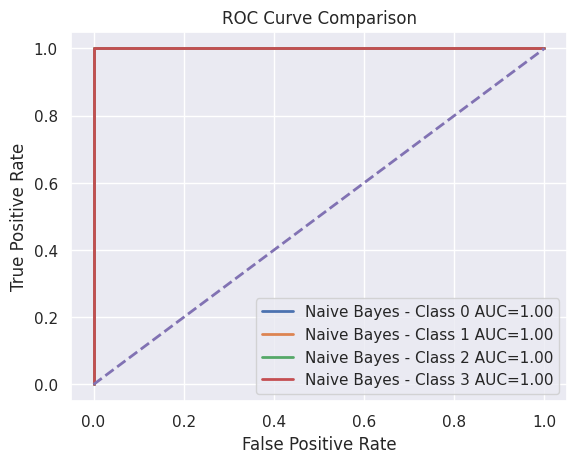


================ MODEL ACCURACY COMPARISON ================

                    Model  Accuracy
1           Decision Tree       1.0
2           Random Forest       1.0
3       Gradient Boosting       1.0
6             Naive Bayes       1.0
0     Logistic Regression       0.6
5     K-Nearest Neighbors       0.6
4  Support Vector Machine       0.4


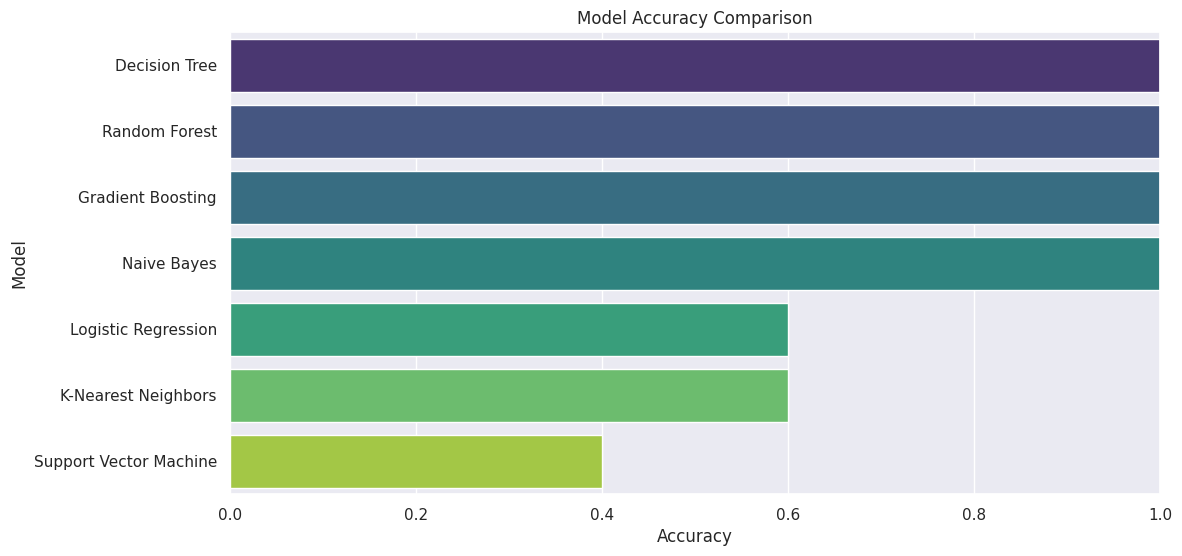


================ FEATURE IMPORTANCE ================

                                          Feature  Importance
1                  mulching_treatment_description    0.148770
0                     experimental_observation_id    0.122795
4                 ambient_air_temperature_celsius    0.121151
12                          leaf_biomass_weight_g    0.052679
11                      seedling_height_increment    0.045755
14                   specific_leaf_area_g_per_cm2    0.043836
23                      carbon_use_efficiency_cue    0.040197
2                           soil_moisture_percent    0.037478
3                        soil_temperature_celsius    0.035774
18  intercellular_carbon_dioxide_concentration_ci    0.033451
25                gross_water_use_efficiency_wueg    0.032880
19                     net_photosynthetic_rate_pn    0.032281
21                   gross_photosynthetic_rate_pg    0.028400
22                        transpiration_rate_mmol    0.024253
20             

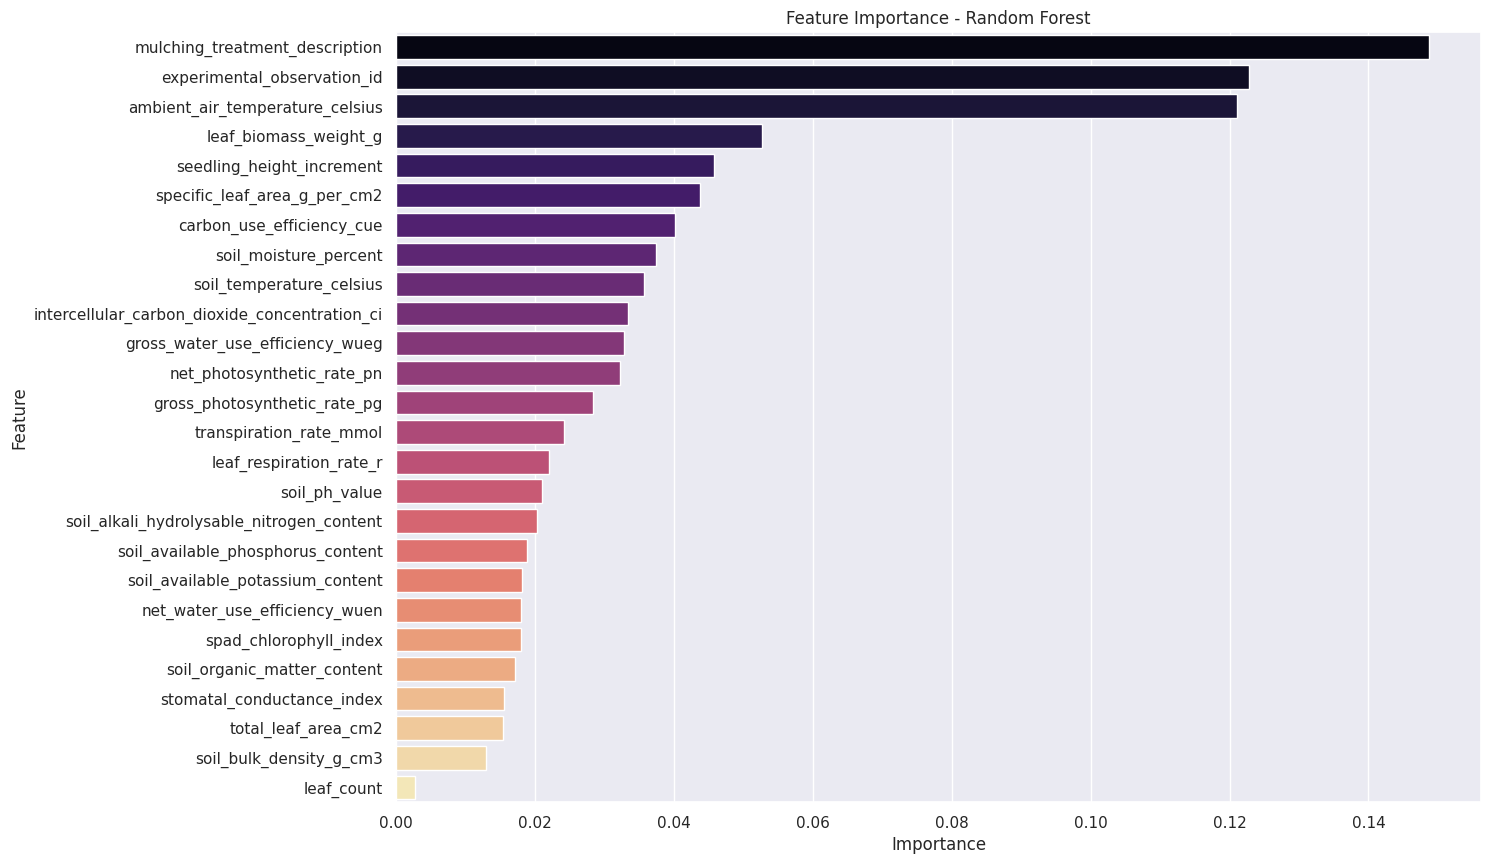


BEST MODEL

Best Model Name : Decision Tree
Best Accuracy   : 1.0

Model Saved Successfully!


In [14]:
# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score


target_column = 'mulching_treatment_code'


target_encoder = LabelEncoder()

df[target_column] = target_encoder.fit_transform(df[target_column])

print("\nEncoded Target Classes:")
print(target_encoder.classes_)


categorical_cols = df.select_dtypes(include=['object']).columns

print("\nCategorical Columns:")
print(categorical_cols)

# Remove target if present
categorical_cols = [col for col in categorical_cols if col != target_column]

# Label Encoding ONLY on Features
feature_encoders = {}

for col in categorical_cols:
    
    le = LabelEncoder()
    
    df[col] = le.fit_transform(df[col].astype(str))
    
    feature_encoders[col] = le


X = df.drop(target_column, axis=1)

y = df[target_column]

# =========================================================
# TRAIN TEST SPLIT
# =========================================================
# IMPORTANT:
# Split BEFORE scaling to avoid data leakage

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

# =========================================================
# FEATURE SCALING
# =========================================================
# FIT ONLY ON TRAIN DATA
# Prevents Data Leakage

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# =========================================================
# MACHINE LEARNING MODELS
# =========================================================

models = {

    "Logistic Regression": LogisticRegression(max_iter=500),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "Support Vector Machine": SVC(
        probability=True,
        random_state=42
    ),

    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Naive Bayes": GaussianNB()
}

# =========================================================
# STORE RESULTS
# =========================================================

accuracy_results = {}

# =========================================================
# ROC CURVE PLOT
# =========================================================

plt.figure(figsize=(12, 8))

# =========================================================
# TRAIN AND EVALUATE MODELS
# =========================================================

for name, model in models.items():

    print("\n===================================================")
    print(f"MODEL : {name}")
    print("===================================================\n")

    # ------------------------------------------------
    # TRAIN MODEL
    # ------------------------------------------------

    model.fit(X_train_scaled, y_train)

    # ------------------------------------------------
    # PREDICTIONS
    # ------------------------------------------------

    y_pred = model.predict(X_test_scaled)

    # ------------------------------------------------
    # ACCURACY
    # ------------------------------------------------

    accuracy = accuracy_score(y_test, y_pred)

    accuracy_results[name] = accuracy

    print(f"Accuracy Score : {accuracy:.4f}")

    # ------------------------------------------------
    # CLASSIFICATION REPORT
    # ------------------------------------------------

    print("\nClassification Report:\n")

    print(classification_report(y_test, y_pred))

    # ------------------------------------------------
    # CONFUSION MATRIX
    # ------------------------------------------------

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'Confusion Matrix - {name}')

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

    # ------------------------------------------------
    # ROC CURVE
    # ------------------------------------------------
    # Multi-class ROC
    # Using One-vs-Rest approach

    try:

        y_prob = model.predict_proba(X_test_scaled)

        # ROC AUC SCORE
        roc_auc = roc_auc_score(
            y_test,
            y_prob,
            multi_class='ovr'
        )

        print(f"ROC-AUC Score : {roc_auc:.4f}")

        # ROC curve for each class
        for i in range(len(np.unique(y))):

            fpr, tpr, thresholds = roc_curve(
                (y_test == i).astype(int),
                y_prob[:, i]
            )

            roc_auc_class = auc(fpr, tpr)

            plt.plot(
                fpr,
                tpr,
                linewidth=2,
                label=f'{name} - Class {i} AUC={roc_auc_class:.2f}'
            )

    except:
        print("ROC Curve not supported for this model.")

# =========================================================
# FINAL ROC CURVE
# =========================================================

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=2
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

# =========================================================
# ACCURACY COMPARISON
# =========================================================

accuracy_df = pd.DataFrame({

    "Model": accuracy_results.keys(),

    "Accuracy": accuracy_results.values()

})

accuracy_df = accuracy_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n================ MODEL ACCURACY COMPARISON ================\n")

print(accuracy_df)

# =========================================================
# BARPLOT OF MODEL ACCURACY
# =========================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    x="Accuracy",
    y="Model",
    data=accuracy_df,
    palette="viridis"
)

plt.title("Model Accuracy Comparison")

plt.xlim(0, 1)

plt.show()

# =========================================================
# FEATURE IMPORTANCE (RANDOM FOREST)
# =========================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

importance = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({

    "Feature": X.columns,

    "Importance": importance

})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\n================ FEATURE IMPORTANCE ================\n")

print(feature_importance_df)

# =========================================================
# FEATURE IMPORTANCE VISUALIZATION
# =========================================================

plt.figure(figsize=(14, 10))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance_df,
    palette="magma"
)

plt.title("Feature Importance - Random Forest")

plt.show()

# =========================================================
# BEST MODEL
# =========================================================

best_model = accuracy_df.iloc[0]

print("\n===================================================")
print("BEST MODEL")
print("===================================================\n")

print("Best Model Name :", best_model["Model"])

print("Best Accuracy   :", round(best_model["Accuracy"], 4))

# =========================================================
# SAVE FINAL MODEL
# =========================================================

import joblib

final_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

final_model.fit(X_train_scaled, y_train)

joblib.dump(final_model, "best_mulching_model.pkl")

joblib.dump(scaler, "scaler.pkl")

print("\nModel Saved Successfully!")

## Thank you...pls upvote!!!!!!!!!!!!!